# Uncertainty-Aware Underwater Semantic Segmentation for Robotics

This notebook builds a reproducible semantic-segmentation pipeline on the **SUIM (Semantic Segmentation of Underwater Imagery)** dataset and checks how well pixel-level uncertainty lines up with actual segmentation errors.

### Research questions
1. How well can a practical DeepLabV3 + MobileNetV3 model segment the eight SUIM classes?
2. Does Monte Carlo Dropout produce uncertainty maps that focus on difficult or incorrect pixels?
3. Does temperature scaling improve probabilistic calibration without changing the predicted class labels?
4. What can the uncertainty signal tell us about conservative underwater robotic perception?

### Dataset provenance
The official SUIM resource describes **1,525 paired train/validation samples** and **110 paired test samples**. Masks are RGB-coded for eight classes: background/waterbody, human divers, aquatic plants/sea-grass, wrecks/ruins, robots/instruments, reefs/invertebrates, fish/vertebrates, and sea-floor/rocks. The official folder structure is `train_val/images`, `train_val/masks`, `TEST/images`, and `TEST/masks`.

Sources: [official SUIM dataset page](https://irvlab.cs.umn.edu/resources/suim-dataset), [official SUIM repository](https://github.com/IRVLab/SUIM).

### Scientific note
No experimental result is hard-coded in this notebook. Metrics, plots, checkpoint files, timing values, and uncertainty statistics are produced only after execution.


## 1. Project Overview

The main architecture is **DeepLabV3 with a MobileNetV3-Large backbone**. It uses an atrous spatial pyramid pooling head, while the MobileNetV3 backbone keeps the compute cost practical for Colab. TorchVision provides a dedicated `deeplabv3_mobilenet_v3_large` builder and ImageNet-pretrained MobileNetV3 weights. The segmentation weights are **not** loaded because their label space does not match SUIM; only the backbone is initialized from ImageNet.

For uncertainty, the notebook uses **Monte Carlo Dropout in the segmentation head**. During stochastic inference, dropout layers stay active while BatchNorm layers remain in evaluation mode. Multiple stochastic passes are used to compute the predictive mean, predictive entropy, expected entropy, mutual-information-style epistemic proxy, and mean class-wise predictive variance.

For calibration, a single scalar temperature is fitted on a deterministic validation-pixel sample by minimizing cross-entropy with L-BFGS. Test-set calibration is then evaluated without refitting on test labels.


In [81]:
# ================================================================
# Cell 1: Setup, configuration, and reproducibility
# ================================================================

!pip -q install gdown

import os
import sys
import json
import math
import time
import random
import shutil
import hashlib
import platform
import zlib
import subprocess
from pathlib import Path
from collections import Counter, defaultdict
from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFile

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.transforms import functional as TF
from torchvision.models.segmentation import deeplabv3_mobilenet_v3_large
from torchvision.models import MobileNet_V3_Large_Weights
from sklearn.model_selection import train_test_split

ImageFile.LOAD_TRUNCATED_IMAGES = False

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
try:
    import torchvision
    print("Torchvision:", torchvision.__version__)
except Exception as exc:
    print("Torchvision version check failed:", exc)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    props = torch.cuda.get_device_properties(0)
    print(f"GPU memory: {props.total_memory / 1024**3:.2f} GB")
else:
    print("GPU: CPU fallback")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = DEVICE.type == "cuda"
print("Selected device:", DEVICE)
print("Mixed precision enabled:", AMP_ENABLED)

# ---------------------------------------------------------------
# Main configuration
# ---------------------------------------------------------------
SEED = 20260827
DATA_ROOT = Path("/content/suim_data")
DOWNLOAD_ROOT = Path("/content/suim_download")
OUTPUT_ROOT = Path("/content/project_outputs")
IMAGE_SIZE = 256
BATCH_SIZE = 8 if DEVICE.type == "cuda" else 2
NUM_WORKERS = min(2, os.cpu_count() or 1)
EPOCHS = 25                          # Use 25 full training epochs.
VAL_FRACTION = 0.15
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
DICE_WEIGHT = 0.6                    # Use a higher Dice weight to give more emphasis to boundary overlap.
AUX_WEIGHT = 0.4
MC_SAMPLES = 8
CALIBRATION_PIXELS = 100_000
EARLY_STOPPING_PATIENCE = 10          # Use a patience of 10 so training has more room to improve.
SMOKE_TEST = False

CLASS_NAMES = [
    "Background / waterbody",
    "Human divers",
    "Aquatic plants / sea-grass",
    "Wrecks / ruins",
    "Robots / instruments",
    "Reefs / invertebrates",
    "Fish / vertebrates",
    "Sea-floor / rocks",
]
NUM_CLASSES = len(CLASS_NAMES)

# SUIM uses the official RGB codes 000, 001, ..., 111.
CLASS_RGB = np.array([
    [0, 0, 0],
    [0, 0, 255],
    [0, 255, 0],
    [0, 255, 255],
    [255, 0, 0],
    [255, 0, 255],
    [255, 255, 0],
    [255, 255, 255],
], dtype=np.uint8)
RGB_TO_CLASS = {tuple(rgb.tolist()): idx for idx, rgb in enumerate(CLASS_RGB)}

for subdir in ["checkpoints", "metrics", "tables", "figures", "predictions", "uncertainty_maps", "logs", "configs"]:
    (OUTPUT_ROOT / subdir).mkdir(parents=True, exist_ok=True)

print(json.dumps({
    "seed": SEED,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "mc_samples": MC_SAMPLES,
    "output_root": str(OUTPUT_ROOT),
}, indent=2))

def stable_seed(base_seed: int, text: str) -> int:
    return int((base_seed + zlib.crc32(text.encode("utf-8"))) % (2**31 - 1))

def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = not torch.cuda.is_available()
    torch.backends.cudnn.deterministic = torch.cuda.is_available()

seed_everything(SEED)

Python: 3.13.15
PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
CUDA available: True
GPU: Tesla T4
GPU memory: 14.56 GB
Selected device: cuda
Mixed precision enabled: True
{
  "seed": 20260827,
  "image_size": 256,
  "batch_size": 8,
  "epochs": 25,
  "learning_rate": 0.0003,
  "early_stopping_patience": 10,
  "mc_samples": 8,
  "output_root": "/content/project_outputs"
}


In [50]:
def stable_seed(base_seed: int, text: str) -> int:
    return int((base_seed + zlib.crc32(text.encode("utf-8"))) % (2**31 - 1))


def seed_everything(seed: int) -> None:
    """Set random seeds used by Python, NumPy, and PyTorch."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = not torch.cuda.is_available()
    torch.backends.cudnn.deterministic = torch.cuda.is_available()

seed_everything(SEED)

## 2. Dataset Download and Validation

The downloader first tries the **official SUIM Google Drive folder** used by the dataset maintainers. A public Kaggle mirror is kept only as a fallback because Drive delivery can occasionally fail during Colab sessions. The validation code does not assume the download is correct: it finds the actual image/mask directories, pairs files by stem, checks readability and dimensions, and verifies the expected color-coded mask values.


In [51]:
# ================================================================
# SUIM dataset: use the existing archive.zip in Google Colab
# Robust version with improved image/mask matching
# ================================================================
#
# Important:
# This version does not open a new upload dialog.
#
# It uses this existing file:
#
#       /content/archive.zip
#
#   which is already present in the Colab filesystem.
#
# How to use:
# 1. Make sure /content/archive.zip exists.
# 2. Run this cell.
# 3. No re-upload is required.
#
# This code:
# - validates the ZIP
# - calculates SHA256
# - extracts it safely
# - detects the official SUIM structure
# - detects the flat suim_merged structure
# - matches images and masks robustly
# - reconstructs semantic masks when needed
# - creates the canonical dataset paths
#
# Official SUIM structure:
#
#   train_val/
#       images/
#       masks/
#
#   TEST/
#       images/
#       masks/
#
# Official benchmark:
#   1525 train/validation
#   110 test
#
# Flat mirror:
#
#   suim_merged/
#       images/
#       masks/
#           BW/
#           HD/
#           PF/
#           WR/
#           RO/
#           RI/
#           FV/
#           SR/
#
# ================================================================


# ================================================================
# 0. Imports
# ================================================================

import os
import re
import shutil
import zipfile
import hashlib
import difflib
from pathlib import Path


# ================================================================
# 1. Use the existing ZIP already in Colab
# ================================================================

print("=" * 80)
print("SUIM DATASET - USING EXISTING /content/archive.zip")
print("=" * 80)
print()
print("No upload dialog will be opened.")
print("The existing archive.zip in /content will be used.")
print()


# ---------------------------------------------------------------
# Primary ZIP path
# ---------------------------------------------------------------
ZIP_PATH = Path("/content/archive.zip")


# ---------------------------------------------------------------
# If archive.zip is missing, look for another ZIP already
# present in /content. This is only a safety fallback; it does not
# open an upload dialog.
# ---------------------------------------------------------------
if not ZIP_PATH.exists():

    print(
        "WARNING: /content/archive.zip was not found."
    )

    existing_zip_candidates = sorted(
        [
            p
            for p in Path("/content").glob("*.zip")
            if p.is_file()
        ],
        key=lambda p: p.name.lower(),
    )

    if not existing_zip_candidates:

        raise RuntimeError(
            "\n"
            "No ZIP archive was found in /content.\n\n"
            "Expected:\n"
            "  /content/archive.zip\n\n"
            "Your Colab file panel should contain archive.zip "
            "before running this cell."
        )

    # Prefer an archive whose filename contains SUIM.
    suim_candidates = [
        p
        for p in existing_zip_candidates
        if "suim" in p.name.lower()
    ]

    if suim_candidates:

        ZIP_PATH = suim_candidates[0]

    else:

        ZIP_PATH = existing_zip_candidates[0]

    print(
        "Using existing ZIP found in /content:"
    )

    print(
        ZIP_PATH
    )


# ---------------------------------------------------------------
# Final existence check
# ---------------------------------------------------------------
if not ZIP_PATH.exists():

    raise RuntimeError(
        f"ZIP file was not found:\n{ZIP_PATH}"
    )


if not ZIP_PATH.is_file():

    raise RuntimeError(
        f"ZIP path is not a regular file:\n{ZIP_PATH}"
    )


print("=" * 80)
print("EXISTING ZIP FILE")
print("=" * 80)

print(
    "Filename :",
    ZIP_PATH.name,
)

print(
    "Path     :",
    ZIP_PATH,
)

print(
    "Size     : "
    f"{ZIP_PATH.stat().st_size / (1024 ** 2):.2f} MB"
)

print()


# ================================================================
# 2. SHA256 checksum
# ================================================================

print("=" * 80)
print("CALCULATING SHA256")
print("=" * 80)


def calculate_sha256(
    path,
    chunk_size=1024 * 1024,
):

    sha256 = hashlib.sha256()

    with open(
        path,
        "rb",
    ) as f:

        while True:

            chunk = f.read(
                chunk_size
            )

            if not chunk:
                break

            sha256.update(
                chunk
            )

    return sha256.hexdigest()


ZIP_SHA256 = calculate_sha256(
    ZIP_PATH
)


print(
    "SHA256:",
    ZIP_SHA256
)

print()


# ================================================================
# 3. Basic ZIP validation
# ================================================================

print("=" * 80)
print("VALIDATING ZIP")
print("=" * 80)


if not zipfile.is_zipfile(
    ZIP_PATH
):

    raise RuntimeError(
        "\n"
        "The existing archive is NOT a valid ZIP archive.\n\n"
        f"File: {ZIP_PATH}\n"
        f"Size: "
        f"{ZIP_PATH.stat().st_size / (1024 ** 2):.2f} MB\n\n"
        "The file may be corrupted or incomplete."
    )


try:

    with zipfile.ZipFile(
        ZIP_PATH,
        "r",
    ) as zf:

        bad_file = zf.testzip()

        if bad_file is not None:

            raise RuntimeError(
                "ZIP integrity test failed.\n"
                f"Corrupted member: {bad_file}"
            )

        zip_members = zf.namelist()

except zipfile.BadZipFile as exc:

    raise RuntimeError(
        "The existing ZIP archive is corrupted."
    ) from exc


print(
    f"ZIP contains {len(zip_members):,} entries."
)

print(
    "ZIP integrity check: PASSED"
)

print()


# ================================================================
# 4. Directories
# ================================================================

UPLOAD_ROOT = (
    Path("/content/SUIM_uploaded")
)

EXTRACT_ROOT = (
    UPLOAD_ROOT / "extracted"
)

DATA_ROOT = (
    Path("/content/SUIM")
)


def create_clean_directory(
    path,
):

    path = Path(path)

    if path.exists():
        shutil.rmtree(path)

    path.mkdir(
        parents=True,
        exist_ok=True,
    )


create_clean_directory(
    UPLOAD_ROOT
)

EXTRACT_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)


# ================================================================
# 5. Safe ZIP extraction
# ================================================================

print("=" * 80)
print("EXTRACTING ZIP")
print("=" * 80)


def extract_zip_safely(
    zip_path,
    destination,
):

    zip_path = Path(zip_path)
    destination = Path(destination)

    destination.mkdir(
        parents=True,
        exist_ok=True,
    )

    destination_resolved = (
        destination.resolve()
    )

    with zipfile.ZipFile(
        zip_path,
        "r",
    ) as zf:

        for member in zf.infolist():

            target = (
                destination
                / member.filename
            ).resolve()

            try:

                target.relative_to(
                    destination_resolved
                )

            except ValueError:

                raise RuntimeError(
                    "Unsafe ZIP path detected:\n"
                    f"{member.filename}"
                )

        zf.extractall(
            destination
        )


extract_zip_safely(
    ZIP_PATH,
    EXTRACT_ROOT,
)


print(
    "Extraction completed successfully."
)

print(
    "Extraction directory:",
    EXTRACT_ROOT,
)

print()


# ================================================================
# 6. Image extensions
# ================================================================

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp",
}


def is_image_file(
    path,
):

    path = Path(path)

    return (
        path.is_file()
        and path.suffix.lower()
        in IMAGE_EXTENSIONS
    )


def list_image_files(
    directory,
):

    directory = Path(directory)

    if not directory.is_dir():
        return []

    return sorted(
        [
            p
            for p in directory.iterdir()
            if is_image_file(p)
        ],
        key=lambda p: p.name.lower(),
    )


def count_images(
    directory,
):

    return len(
        list_image_files(
            directory
        )
    )


# ================================================================
# 7. Name normalization
# ================================================================

def normalize_name(
    name,
):

    return re.sub(
        r"[^a-z0-9]+",
        "_",
        str(name).lower(),
    ).strip("_")


def compact_name(
    name,
):
    """
    More aggressive normalization.

    Examples:

        f_r_1438_        -> fr1438
        f-r-1438         -> fr1438
        f_r_1438_mask    -> fr1438mask
    """

    normalized = normalize_name(
        name
    )

    return re.sub(
        r"[^a-z0-9]",
        "",
        normalized,
    )


def remove_common_mask_suffixes(
    stem,
):
    """
    Remove harmless naming variations frequently found in
    image/mask datasets.
    """

    value = normalize_name(
        stem
    )

    patterns = [
        r"_mask$",
        r"_masks$",
        r"_label$",
        r"_labels$",
        r"_annotation$",
        r"_annotations$",
        r"_gt$",
        r"_ground_truth$",
        r"_seg$",
        r"_segmentation$",
    ]

    changed = True

    while changed:

        changed = False

        for pattern in patterns:

            new_value = re.sub(
                pattern,
                "",
                value,
            )

            if new_value != value:

                value = new_value
                changed = True

    return value.strip("_")


def extract_numeric_signature(
    stem,
):
    """
    Extract the complete trailing numeric component.

    Example:

        f_r_1438_ -> 1438
        wr_12     -> 12
    """

    value = normalize_name(
        stem
    )

    numbers = re.findall(
        r"\d+",
        value,
    )

    if not numbers:
        return None

    return numbers[-1]


# ================================================================
# 8. Official SUIM directory names
# ================================================================

TRAIN_NAMES = {
    "train_val",
    "trainval",
    "train_validation",
    "train_valid",
    "training_validation",
    "train",
}


TEST_NAMES = {
    "test",
    "test_set",
    "testing",
}


IMAGE_DIR_NAMES = {
    "images",
    "image",
    "imgs",
    "img",
}


MASK_DIR_NAMES = {
    "masks",
    "mask",
    "labels",
    "label",
    "annotations",
    "annotation",
}


# ================================================================
# 9. Find the official train/test structure
# ================================================================

def find_official_splits(
    root,
):

    root = Path(root)

    train_candidates = []
    test_candidates = []

    normalized_image_names = {
        normalize_name(x)
        for x in IMAGE_DIR_NAMES
    }

    normalized_mask_names = {
        normalize_name(x)
        for x in MASK_DIR_NAMES
    }

    all_dirs = [
        p
        for p in root.rglob("*")
        if p.is_dir()
    ]

    for split_dir in all_dirs:

        split_name = normalize_name(
            split_dir.name
        )

        if (
            split_name not in TRAIN_NAMES
            and split_name not in TEST_NAMES
        ):
            continue

        try:

            child_dirs = [
                p
                for p in split_dir.iterdir()
                if p.is_dir()
            ]

        except OSError:

            continue

        image_dir = None
        mask_dir = None

        for child in child_dirs:

            child_name = normalize_name(
                child.name
            )

            if (
                child_name
                in normalized_image_names
                and count_images(child) > 0
            ):

                image_dir = child
                break

        for child in child_dirs:

            child_name = normalize_name(
                child.name
            )

            if (
                child_name
                in normalized_mask_names
                and count_images(child) > 0
            ):

                mask_dir = child
                break

        if (
            image_dir is None
            or mask_dir is None
        ):
            continue

        record = (
            count_images(image_dir),
            split_dir,
            image_dir,
            mask_dir,
        )

        if split_name in TRAIN_NAMES:

            train_candidates.append(
                record
            )

        elif split_name in TEST_NAMES:

            test_candidates.append(
                record
            )

    train_candidates.sort(
        key=lambda x: x[0],
        reverse=True,
    )

    test_candidates.sort(
        key=lambda x: x[0],
        reverse=True,
    )

    if (
        not train_candidates
        or not test_candidates
    ):

        return None

    (
        _,
        train_split,
        train_images,
        train_masks,
    ) = train_candidates[0]

    (
        _,
        test_split,
        test_images,
        test_masks,
    ) = test_candidates[0]

    return {
        "type": "official",
        "train_split": train_split,
        "train_images": train_images,
        "train_masks": train_masks,
        "test_split": test_split,
        "test_images": test_images,
        "test_masks": test_masks,
    }


# ================================================================
# 10. Robust image/mask matching
# ================================================================

def build_stem_map(
    directory,
):

    result = {}

    for path in list_image_files(
        directory
    ):

        key = path.stem.lower()

        if key not in result:
            result[key] = path

    return result


def robust_match_paths(
    image_dir,
    mask_dir,
    verbose=True,
):

    image_files = list_image_files(
        image_dir
    )

    mask_files = list_image_files(
        mask_dir
    )

    # ------------------------------------------------------------
    # Lookup maps
    # ------------------------------------------------------------
    exact_images = {
        p.stem.lower(): p
        for p in image_files
    }

    exact_masks = {
        p.stem.lower(): p
        for p in mask_files
    }

    # ------------------------------------------------------------
    # Result dictionaries
    # ------------------------------------------------------------
    matches = {}

    used_masks = set()

    exact_count = 0
    normalized_count = 0
    compact_count = 0
    numeric_count = 0
    fuzzy_count = 0

    # ------------------------------------------------------------
    # Pass 1:
    # Exact stem
    # ------------------------------------------------------------
    for image_stem, image_path in (
        exact_images.items()
    ):

        mask_path = exact_masks.get(
            image_stem
        )

        if mask_path is not None:

            matches[image_stem] = (
                image_path,
                mask_path,
                "exact",
            )

            used_masks.add(
                str(mask_path)
            )

            exact_count += 1

    # ------------------------------------------------------------
    # Pass 2:
    # Handle common mask suffixes
    # ------------------------------------------------------------
    normalized_mask_map = {}

    for mask_path in mask_files:

        if str(mask_path) in used_masks:
            continue

        key = remove_common_mask_suffixes(
            mask_path.stem
        )

        if key not in normalized_mask_map:
            normalized_mask_map[key] = []

        normalized_mask_map[key].append(
            mask_path
        )

    for image_stem, image_path in (
        exact_images.items()
    ):

        if image_stem in matches:
            continue

        key = remove_common_mask_suffixes(
            image_path.stem
        )

        candidates = [
            p
            for p in normalized_mask_map.get(
                key,
                [],
            )
            if str(p) not in used_masks
        ]

        if len(candidates) == 1:

            mask_path = candidates[0]

            matches[image_stem] = (
                image_path,
                mask_path,
                "normalized",
            )

            used_masks.add(
                str(mask_path)
            )

            normalized_count += 1

    # ------------------------------------------------------------
    # Pass 3:
    # Compact alphanumeric normalization
    # ------------------------------------------------------------
    compact_mask_map = {}

    for mask_path in mask_files:

        if str(mask_path) in used_masks:
            continue

        key = compact_name(
            remove_common_mask_suffixes(
                mask_path.stem
            )
        )

        if key not in compact_mask_map:
            compact_mask_map[key] = []

        compact_mask_map[key].append(
            mask_path
        )

    for image_stem, image_path in (
        exact_images.items()
    ):

        if image_stem in matches:
            continue

        key = compact_name(
            remove_common_mask_suffixes(
                image_path.stem
            )
        )

        candidates = [
            p
            for p in compact_mask_map.get(
                key,
                [],
            )
            if str(p) not in used_masks
        ]

        if len(candidates) == 1:

            mask_path = candidates[0]

            matches[image_stem] = (
                image_path,
                mask_path,
                "compact",
            )

            used_masks.add(
                str(mask_path)
            )

            compact_count += 1

    # ------------------------------------------------------------
    # Pass 4:
    # Unique numeric signature
    #
    # Use this only when the numeric signature maps to exactly one
    # unused mask.
    # ------------------------------------------------------------
    numeric_mask_map = {}

    for mask_path in mask_files:

        if str(mask_path) in used_masks:
            continue

        signature = extract_numeric_signature(
            mask_path.stem
        )

        if signature is None:
            continue

        if signature not in numeric_mask_map:
            numeric_mask_map[signature] = []

        numeric_mask_map[signature].append(
            mask_path
        )

    for image_stem, image_path in (
        exact_images.items()
    ):

        if image_stem in matches:
            continue

        signature = extract_numeric_signature(
            image_path.stem
        )

        if signature is None:
            continue

        candidates = [
            p
            for p in numeric_mask_map.get(
                signature,
                [],
            )
            if str(p) not in used_masks
        ]

        if len(candidates) == 1:

            mask_path = candidates[0]

            matches[image_stem] = (
                image_path,
                mask_path,
                "numeric",
            )

            used_masks.add(
                str(mask_path)
            )

            numeric_count += 1

    # ------------------------------------------------------------
    # Pass 5:
    # High-confidence fuzzy matching
    # ------------------------------------------------------------
    remaining_images = [
        p
        for p in image_files
        if p.stem.lower()
        not in matches
    ]

    remaining_masks = [
        p
        for p in mask_files
        if str(p) not in used_masks
    ]

    normalized_remaining_masks = {
        p: compact_name(
            remove_common_mask_suffixes(
                p.stem
            )
        )
        for p in remaining_masks
    }

    for image_path in remaining_images:

        image_key = compact_name(
            remove_common_mask_suffixes(
                image_path.stem
            )
        )

        if not image_key:
            continue

        scored = []

        for mask_path, mask_key in (
            normalized_remaining_masks.items()
        ):

            if str(mask_path) in used_masks:
                continue

            ratio = difflib.SequenceMatcher(
                None,
                image_key,
                mask_key,
            ).ratio()

            scored.append(
                (
                    ratio,
                    mask_path,
                )
            )

        scored.sort(
            key=lambda x: x[0],
            reverse=True,
        )

        if not scored:
            continue

        best_score, best_mask = (
            scored[0]
        )

        second_score = (
            scored[1][0]
            if len(scored) > 1
            else 0.0
        )

        if (
            best_score >= 0.93
            and (
                best_score
                - second_score
                >= 0.03
                or second_score == 0.0
            )
        ):

            matches[
                image_path.stem.lower()
            ] = (
                image_path,
                best_mask,
                "fuzzy",
            )

            used_masks.add(
                str(best_mask)
            )

            fuzzy_count += 1

    # ------------------------------------------------------------
    # Unmatched files
    # ------------------------------------------------------------
    unmatched_images = [
        p
        for p in image_files
        if p.stem.lower()
        not in matches
    ]

    unmatched_masks = [
        p
        for p in mask_files
        if str(p) not in used_masks
    ]

    if verbose:

        print()
        print("-" * 80)
        print("ROBUST IMAGE/MASK MATCHING")
        print("-" * 80)

        print(
            f"Images found           : {len(image_files):,}"
        )

        print(
            f"Masks found            : {len(mask_files):,}"
        )

        print(
            f"Exact matches          : {exact_count:,}"
        )

        print(
            f"Normalized matches     : {normalized_count:,}"
        )

        print(
            f"Compact matches        : {compact_count:,}"
        )

        print(
            f"Numeric matches        : {numeric_count:,}"
        )

        print(
            f"High-confidence fuzzy  : {fuzzy_count:,}"
        )

        print(
            f"Total matched          : {len(matches):,}"
        )

        print(
            f"Unmatched images       : {len(unmatched_images):,}"
        )

        print(
            f"Unmatched masks        : {len(unmatched_masks):,}"
        )

        print("-" * 80)

        if unmatched_images:

            print()
            print(
                "Remaining unmatched images:"
            )

            for p in unmatched_images[:30]:

                print(
                    "  IMAGE:",
                    p.name,
                )

        if unmatched_masks:

            print()
            print(
                "Remaining unmatched masks:"
            )

            for p in unmatched_masks[:30]:

                print(
                    "  MASK :",
                    p.name,
                )

        print("-" * 80)

    return {
        "matches": matches,
        "unmatched_images": unmatched_images,
        "unmatched_masks": unmatched_masks,
        "image_files": image_files,
        "mask_files": mask_files,
    }


# ================================================================
# 11. Official image/mask pair validation
# ================================================================

def validate_official_dataset(
    layout,
):

    if layout is None:
        return False

    train_match = robust_match_paths(
        layout["train_images"],
        layout["train_masks"],
        verbose=True,
    )

    test_match = robust_match_paths(
        layout["test_images"],
        layout["test_masks"],
        verbose=True,
    )

    train_pairs = len(
        train_match["matches"]
    )

    test_pairs = len(
        test_match["matches"]
    )

    print()
    print("=" * 80)
    print("OFFICIAL-STYLE SUIM VALIDATION")
    print("=" * 80)

    print(
        "Train pairs:",
        train_pairs,
    )

    print(
        "Test pairs :",
        test_pairs,
    )

    print("=" * 80)

    return (
        train_pairs > 0
        and test_pairs > 0
    )


# ================================================================
# 12. Detect the flat suim_merged structure
# ================================================================

SUIM_CLASSES = {
    "bw": 0,
    "hd": 1,
    "pf": 2,
    "wr": 3,
    "ro": 4,
    "ri": 5,
    "fv": 6,
    "sr": 7,
}


def find_flat_suim_merged(
    root,
):

    root = Path(root)

    image_candidates = []
    mask_candidates = []

    normalized_image_names = {
        normalize_name(x)
        for x in IMAGE_DIR_NAMES
    }

    # ------------------------------------------------------------
    # Find image directories
    # ------------------------------------------------------------
    for p in root.rglob("*"):

        if not p.is_dir():
            continue

        if (
            normalize_name(p.name)
            not in normalized_image_names
        ):
            continue

        n = count_images(p)

        if n > 0:

            image_candidates.append(
                (
                    n,
                    p,
                )
            )

    # ------------------------------------------------------------
    # Find mask roots
    # ------------------------------------------------------------
    for p in root.rglob("*"):

        if not p.is_dir():
            continue

        if (
            normalize_name(p.name)
            not in {
                "masks",
                "mask",
            }
        ):
            continue

        try:

            children = [
                x
                for x in p.iterdir()
                if x.is_dir()
            ]

        except OSError:

            continue

        class_dirs = []

        for child in children:

            class_name = normalize_name(
                child.name
            )

            if (
                class_name in SUIM_CLASSES
                and count_images(child) > 0
            ):

                class_dirs.append(
                    child
                )

        if class_dirs:

            total = sum(
                count_images(x)
                for x in class_dirs
            )

            mask_candidates.append(
                (
                    total,
                    p,
                )
            )

    if (
        not image_candidates
        or not mask_candidates
    ):

        return None

    image_candidates.sort(
        key=lambda x: x[0],
        reverse=True,
    )

    mask_candidates.sort(
        key=lambda x: x[0],
        reverse=True,
    )

    return {
        "type": "flat",
        "images": image_candidates[0][1],
        "masks": mask_candidates[0][1],
    }


# ================================================================
# 13. Discover the dataset structure
# ================================================================

print("=" * 80)
print("SEARCHING EXTRACTED DATASET")
print("=" * 80)


official_layout = (
    find_official_splits(
        EXTRACT_ROOT
    )
)


flat_layout = None


if official_layout is not None:

    print()
    print(
        "Detected OFFICIAL SUIM-style structure."
    )

    print()

    print(
        "Train split :",
        official_layout["train_split"],
    )

    print(
        "Train images:",
        official_layout["train_images"],
    )

    print(
        "Train masks :",
        official_layout["train_masks"],
    )

    print()

    print(
        "Test split  :",
        official_layout["test_split"],
    )

    print(
        "Test images :",
        official_layout["test_images"],
    )

    print(
        "Test masks  :",
        official_layout["test_masks"],
    )

else:

    print(
        "Official train_val/TEST structure "
        "was not detected."
    )

    print(
        "Checking for flat suim_merged layout..."
    )

    flat_layout = (
        find_flat_suim_merged(
            EXTRACT_ROOT
        )
    )

    if flat_layout is None:

        print()
        print("=" * 80)
        print(
            "DATASET STRUCTURE COULD NOT BE DETECTED"
        )
        print("=" * 80)

        print()

        top_entries = sorted(
            EXTRACT_ROOT.iterdir(),
            key=lambda p: p.name.lower(),
        )

        for entry in top_entries[:100]:

            marker = (
                "[D]"
                if entry.is_dir()
                else "[F]"
            )

            print(
                f"{marker} {entry.name}"
            )

        raise RuntimeError(
            "\n"
            "Could not recognize the existing ZIP "
            "as a supported SUIM dataset.\n\n"
            "Expected either:\n\n"
            "1) Official SUIM:\n"
            "   train_val/images\n"
            "   train_val/masks\n"
            "   TEST/images\n"
            "   TEST/masks\n\n"
            "OR:\n\n"
            "2) Flat mirror:\n"
            "   suim_merged/images\n"
            "   suim_merged/masks/<class>\n"
        )


# ================================================================
# 14. Official SUIM path
# ================================================================

if official_layout is not None:

    print()
    print("=" * 80)
    print(
        "PROCESSING OFFICIAL SUIM STRUCTURE"
    )
    print("=" * 80)

    train_matching = robust_match_paths(
        official_layout["train_images"],
        official_layout["train_masks"],
        verbose=True,
    )

    test_matching = robust_match_paths(
        official_layout["test_images"],
        official_layout["test_masks"],
        verbose=True,
    )

    if (
        len(train_matching["matches"]) == 0
        or len(test_matching["matches"]) == 0
    ):

        raise RuntimeError(
            "\n"
            "The official-style structure was detected, "
            "but valid image/mask pairs could not be "
            "constructed."
        )

    # ------------------------------------------------------------
    # Canonical output
    # ------------------------------------------------------------
    create_clean_directory(
        DATA_ROOT
    )

    canonical_train_images = (
        DATA_ROOT
        / "train_val"
        / "images"
    )

    canonical_train_masks = (
        DATA_ROOT
        / "train_val"
        / "masks"
    )

    canonical_test_images = (
        DATA_ROOT
        / "TEST"
        / "images"
    )

    canonical_test_masks = (
        DATA_ROOT
        / "TEST"
        / "masks"
    )

    for directory in [
        canonical_train_images,
        canonical_train_masks,
        canonical_test_images,
        canonical_test_masks,
    ]:

        directory.mkdir(
            parents=True,
            exist_ok=True,
        )

    # ------------------------------------------------------------
    # Copy matched train pairs
    # ------------------------------------------------------------
    print()
    print(
        "Copying validated train/validation pairs..."
    )

    for (
        index,
        (
            stem,
            (
                image_path,
                mask_path,
                match_type,
            ),
        ),
    ) in enumerate(
        train_matching["matches"].items(),
        start=1,
    ):

        shutil.copy2(
            image_path,
            canonical_train_images
            / image_path.name,
        )

        shutil.copy2(
            mask_path,
            canonical_train_masks
            / mask_path.name,
        )

        if (
            index % 250 == 0
            or index
            == len(
                train_matching["matches"]
            )
        ):

            print(
                "\r"
                f"Train copied: "
                f"{index}/"
                f"{len(train_matching['matches'])}",
                end="",
            )

    print()

    # ------------------------------------------------------------
    # Copy matched test pairs
    # ------------------------------------------------------------
    print(
        "Copying validated test pairs..."
    )

    for (
        index,
        (
            stem,
            (
                image_path,
                mask_path,
                match_type,
            ),
        ),
    ) in enumerate(
        test_matching["matches"].items(),
        start=1,
    ):

        shutil.copy2(
            image_path,
            canonical_test_images
            / image_path.name,
        )

        shutil.copy2(
            mask_path,
            canonical_test_masks
            / mask_path.name,
        )

        if (
            index % 25 == 0
            or index
            == len(
                test_matching["matches"]
            )
        ):

            print(
                "\r"
                f"Test copied: "
                f"{index}/"
                f"{len(test_matching['matches'])}",
                end="",
            )

    print()

    TRAIN_IMG_DIR = (
        canonical_train_images
    )

    TRAIN_MASK_DIR = (
        canonical_train_masks
    )

    TEST_IMG_DIR = (
        canonical_test_images
    )

    TEST_MASK_DIR = (
        canonical_test_masks
    )

    DATASET_SOURCE_TYPE = (
        "OFFICIAL_SUIM_STYLE"
    )


# ================================================================
# 15. Process the flat suim_merged structure
# ================================================================

else:

    print()
    print("=" * 80)
    print(
        "PROCESSING FLAT SUIM_MERGED STRUCTURE"
    )
    print("=" * 80)

    print()
    print(
        "Images:",
        flat_layout["images"],
    )

    print(
        "Masks :",
        flat_layout["masks"],
    )

    # ------------------------------------------------------------
    # Discover class directories
    # ------------------------------------------------------------
    class_directories = [
        p
        for p in flat_layout["masks"].iterdir()
        if (
            p.is_dir()
            and normalize_name(p.name)
            in SUIM_CLASSES
        )
    ]

    if not class_directories:

        raise RuntimeError(
            "\n"
            "No SUIM class mask directories were found."
        )

    # ------------------------------------------------------------
    # Build the image map
    # ------------------------------------------------------------
    flat_image_files = (
        list_image_files(
            flat_layout["images"]
        )
    )

    image_map = {
        p.stem.lower(): p
        for p in flat_image_files
    }

    print()
    print(
        "Flat images:",
        len(flat_image_files),
    )

    # ------------------------------------------------------------
    # Collect all class-wise masks
    # ------------------------------------------------------------
    all_mask_files = []

    for class_dir in sorted(
        class_directories,
        key=lambda p: p.name.lower(),
    ):

        class_name = normalize_name(
            class_dir.name
        )

        class_files = (
            list_image_files(
                class_dir
            )
        )

        print(
            f"  {class_name.upper():>3s}: "
            f"{len(class_files):,} mask files"
        )

        for mask_path in class_files:

            all_mask_files.append(
                (
                    SUIM_CLASSES[
                        class_name
                    ],
                    mask_path,
                    class_name,
                )
            )

    print()
    print(
        "Total class-wise mask files:",
        len(all_mask_files),
    )

    # ------------------------------------------------------------
    # Build aggregate records.
    # ------------------------------------------------------------
    records = {}

    used_mask_paths = set()

    # ------------------------------------------------------------
    # Build image lookup structures
    # ------------------------------------------------------------
    image_items = list(
        image_map.items()
    )

    normalized_image_map = {}

    compact_image_map = {}

    numeric_image_map = {}

    for (
        stem,
        image_path,
    ) in image_items:

        normalized_key = (
            remove_common_mask_suffixes(
                stem
            )
        )

        compact_key = compact_name(
            normalized_key
        )

        numeric_key = (
            extract_numeric_signature(
                stem
            )
        )

        normalized_image_map.setdefault(
            normalized_key,
            [],
        ).append(
            image_path
        )

        compact_image_map.setdefault(
            compact_key,
            [],
        ).append(
            image_path
        )

        if numeric_key is not None:

            numeric_image_map.setdefault(
                numeric_key,
                [],
            ).append(
                image_path
            )

    # ------------------------------------------------------------
    # Process every class-wise mask.
    # ------------------------------------------------------------
    #
    # Treat each mask class directory separately.
    # Multiple class masks can therefore point to the same image.
    # ------------------------------------------------------------

    exact_count = 0
    normalized_count = 0
    compact_count = 0
    numeric_count = 0
    fuzzy_count = 0

    for (
        class_id,
        mask_path,
        class_name,
    ) in all_mask_files:

        matched_image = None
        match_type = None

        # --------------------------------------------------------
        # Pass A - exact stem
        # --------------------------------------------------------
        exact_key = (
            mask_path.stem.lower()
        )

        if exact_key in image_map:

            matched_image = image_map[
                exact_key
            ]

            match_type = "exact"

            exact_count += 1

        # --------------------------------------------------------
        # Pass B - normalized stem
        # --------------------------------------------------------
        if matched_image is None:

            mask_key = (
                remove_common_mask_suffixes(
                    mask_path.stem
                )
            )

            candidates = (
                normalized_image_map.get(
                    mask_key,
                    [],
                )
            )

            if len(candidates) == 1:

                matched_image = candidates[0]

                match_type = (
                    "normalized"
                )

                normalized_count += 1

        # --------------------------------------------------------
        # Pass C - compact normalized stem
        # --------------------------------------------------------
        if matched_image is None:

            mask_key = compact_name(
                remove_common_mask_suffixes(
                    mask_path.stem
                )
            )

            candidates = (
                compact_image_map.get(
                    mask_key,
                    [],
                )
            )

            if len(candidates) == 1:

                matched_image = candidates[0]

                match_type = (
                    "compact"
                )

                compact_count += 1

        # --------------------------------------------------------
        # Pass D - numeric signature
        # --------------------------------------------------------
        if matched_image is None:

            numeric_key = (
                extract_numeric_signature(
                    mask_path.stem
                )
            )

            if numeric_key is not None:

                candidates = (
                    numeric_image_map.get(
                        numeric_key,
                        [],
                    )
                )

                if len(candidates) == 1:

                    matched_image = (
                        candidates[0]
                    )

                    match_type = (
                        "numeric"
                    )

                    numeric_count += 1

        # --------------------------------------------------------
        # Pass E - high-confidence fuzzy match
        # --------------------------------------------------------
        if matched_image is None:

            mask_key = compact_name(
                remove_common_mask_suffixes(
                    mask_path.stem
                )
            )

            scored = []

            for image_path in (
                flat_image_files
            ):

                image_key = compact_name(
                    remove_common_mask_suffixes(
                        image_path.stem
                    )
                )

                ratio = (
                    difflib.SequenceMatcher(
                        None,
                        mask_key,
                        image_key,
                    ).ratio()
                )

                scored.append(
                    (
                        ratio,
                        image_path,
                    )
                )

            scored.sort(
                key=lambda x: x[0],
                reverse=True,
            )

            if scored:

                best_score, best_image = (
                    scored[0]
                )

                second_score = (
                    scored[1][0]
                    if len(scored) > 1
                    else 0.0
                )

                if (
                    best_score >= 0.93
                    and (
                        best_score
                        - second_score
                        >= 0.03
                        or second_score == 0.0
                    )
                ):

                    matched_image = (
                        best_image
                    )

                    match_type = (
                        "fuzzy"
                    )

                    fuzzy_count += 1

        # --------------------------------------------------------
        # Save a successful match.
        # --------------------------------------------------------
        if matched_image is not None:

            stem = (
                matched_image.stem.lower()
            )

            if stem not in records:

                records[stem] = {
                    "image":
                        matched_image,
                    "masks":
                        [],
                }

            records[stem][
                "masks"
            ].append(
                (
                    class_id,
                    mask_path,
                    class_name,
                    match_type,
                )
            )

            used_mask_paths.add(
                str(mask_path)
            )

    # ------------------------------------------------------------
    # Final records
    # ------------------------------------------------------------
    matched_stems = sorted(
        records.keys()
    )

    unmatched_images = [
        p
        for p in flat_image_files
        if p.stem.lower()
        not in records
    ]

    unmatched_masks = [
        mask_path
        for (
            class_id,
            mask_path,
            class_name,
        ) in all_mask_files
        if str(mask_path)
        not in used_mask_paths
    ]

    print()
    print("=" * 80)
    print("FINAL FLAT MIRROR MATCHING")
    print("=" * 80)

    print(
        "Images found        :",
        len(flat_image_files),
    )

    print(
        "Masks found         :",
        len(all_mask_files),
    )

    print(
        "Exact matches       :",
        exact_count,
    )

    print(
        "Normalized matches  :",
        normalized_count,
    )

    print(
        "Compact matches     :",
        compact_count,
    )

    print(
        "Numeric matches     :",
        numeric_count,
    )

    print(
        "Fuzzy matches       :",
        fuzzy_count,
    )

    print(
        "Matched images      :",
        len(matched_stems),
    )

    print(
        "Unmatched images    :",
        len(unmatched_images),
    )

    print(
        "Unmatched masks     :",
        len(unmatched_masks),
    )

    print("=" * 80)

    # ------------------------------------------------------------
    # Diagnostics
    # ------------------------------------------------------------
    if unmatched_images:

        print()
        print(
            "UNMATCHED IMAGE FILES:"
        )

        for image_path in unmatched_images[
            :50
        ]:

            print(
                "  IMAGE:",
                image_path.name,
            )

    if unmatched_masks:

        print()
        print(
            "UNMATCHED MASK FILES:"
        )

        for mask_path in unmatched_masks[
            :50
        ]:

            print(
                "  MASK :",
                mask_path.name,
            )

    # ------------------------------------------------------------
    # Make sure enough samples are available.
    # ------------------------------------------------------------
    if len(matched_stems) < 111:

        raise RuntimeError(
            "\n"
            "Too few matched SUIM samples were found.\n\n"
            f"Matched samples: {len(matched_stems)}\n\n"
            "The existing archive does not appear to contain "
            "a usable SUIM image/mask dataset."
        )

    # ------------------------------------------------------------
    # Requested canonical split:
    #
    # Preferred split:
    #   1525 train
    #   110 test
    #
    # If fewer than 1635 validated samples exist:
    # - preserve all validated samples
    # - reserve 110 for test
    #
    # No masks are invented.
    # ------------------------------------------------------------
    total_pairs = len(
        matched_stems
    )

    if total_pairs >= 1635:

        train_count = 1525
        test_count = 110

        split_status = (
            "DERIVED 1525/110"
        )

    else:

        test_count = 110

        train_count = (
            total_pairs
            - test_count
        )

        split_status = (
            "DERIVED "
            f"{train_count}/{test_count}"
        )

    # ------------------------------------------------------------
    # Keep the ordering deterministic.
    # ------------------------------------------------------------
    matched_stems = sorted(
        matched_stems
    )

    train_stems = matched_stems[
        :train_count
    ]

    test_stems = matched_stems[
        train_count:
        train_count + test_count
    ]

    # ------------------------------------------------------------
    # Canonical directories
    # ------------------------------------------------------------
    create_clean_directory(
        DATA_ROOT
    )

    canonical_train_images = (
        DATA_ROOT
        / "train_val"
        / "images"
    )

    canonical_train_masks = (
        DATA_ROOT
        / "train_val"
        / "masks"
    )

    canonical_test_images = (
        DATA_ROOT
        / "TEST"
        / "images"
    )

    canonical_test_masks = (
        DATA_ROOT
        / "TEST"
        / "masks"
    )

    for directory in [
        canonical_train_images,
        canonical_train_masks,
        canonical_test_images,
        canonical_test_masks,
    ]:

        directory.mkdir(
            parents=True,
            exist_ok=True,
        )

    # ------------------------------------------------------------
    # Need PIL and NumPy
    # ------------------------------------------------------------
    try:

        import numpy as np
        from PIL import Image

    except ImportError as exc:

        raise RuntimeError(
            "Pillow and NumPy are required."
        ) from exc

    # ------------------------------------------------------------
    # Semantic mask generator
    # ------------------------------------------------------------
    def create_semantic_mask(
        mask_items,
        output_path,
    ):
        """
        Combine class-wise binary masks into one semantic mask.

        Values:
            0 = BW
            1 = HD
            2 = PF
            3 = WR
            4 = RO
            5 = RI
            6 = FV
            7 = SR
        """

        if not mask_items:

            raise RuntimeError(
                "No mask files supplied."
            )

        # Sort first so the process stays deterministic.
        mask_items = sorted(
            mask_items,
            key=lambda item: (
                item[0],
                str(item[1]).lower(),
            ),
        )

        first_mask = Image.open(
            mask_items[0][1]
        ).convert("L")

        width, height = (
            first_mask.size
        )

        result = np.zeros(
            (
                height,
                width,
            ),
            dtype=np.uint8,
        )

        for (
            class_id,
            mask_path,
            class_name,
            match_type,
        ) in mask_items:

            current = Image.open(
                mask_path
            ).convert("L")

            if current.size != (
                width,
                height,
            ):

                raise RuntimeError(
                    "\n"
                    "Mask resolution mismatch.\n"
                    f"Expected: {(width, height)}\n"
                    f"Found   : {current.size}\n"
                    f"File    : {mask_path}"
                )

            array = np.asarray(
                current
            )

            foreground = (
                array > 0
            )

            result[
                foreground
            ] = np.uint8(
                class_id
            )

        Image.fromarray(
            result,
            mode="L",
        ).save(
            output_path
        )

    # ------------------------------------------------------------
    # Materialize a sample
    # ------------------------------------------------------------
    def materialize_sample(
        stem,
        image_destination,
        mask_destination,
    ):

        record = records[
            stem
        ]

        image_path = Path(
            record["image"]
        )

        # Copy the original image.
        shutil.copy2(
            image_path,
            image_destination
            / image_path.name,
        )

        # Save the canonical semantic mask.
        semantic_mask_path = (
            mask_destination
            / f"{image_path.stem}.bmp"
        )

        mask_items = sorted(
            record["masks"],
            key=lambda item: (
                item[0],
                str(item[1]).lower(),
            ),
        )

        create_semantic_mask(
            mask_items,
            semantic_mask_path,
        )

    # ------------------------------------------------------------
    # Generate TRAIN
    # ------------------------------------------------------------
    print()
    print("=" * 80)
    print(
        "GENERATING DERIVED TRAIN/VALIDATION SET"
    )
    print("=" * 80)

    print()
    print(
        "Split:",
        split_status,
    )

    print()

    for (
        index,
        stem,
    ) in enumerate(
        train_stems,
        start=1,
    ):

        materialize_sample(
            stem,
            canonical_train_images,
            canonical_train_masks,
        )

        if (
            index % 250 == 0
            or index
            == len(train_stems)
        ):

            print(
                "\r"
                f"Train processed: "
                f"{index}/"
                f"{len(train_stems)}",
                end="",
            )

    print()

    # ------------------------------------------------------------
    # Generate TEST
    # ------------------------------------------------------------
    print()
    print(
        "GENERATING DERIVED TEST SET"
    )

    print()

    for (
        index,
        stem,
    ) in enumerate(
        test_stems,
        start=1,
    ):

        materialize_sample(
            stem,
            canonical_test_images,
            canonical_test_masks,
        )

        if (
            index % 25 == 0
            or index
            == len(test_stems)
        ):

            print(
                "\r"
                f"Test processed: "
                f"{index}/"
                f"{len(test_stems)}",
                end="",
            )

    print()

    TRAIN_IMG_DIR = (
        canonical_train_images
    )

    TRAIN_MASK_DIR = (
        canonical_train_masks
    )

    TEST_IMG_DIR = (
        canonical_test_images
    )

    TEST_MASK_DIR = (
        canonical_test_masks
    )

    DATASET_SOURCE_TYPE = (
        "FLAT_SUIM_MERGED_DERIVED"
    )


# ================================================================
# 16. Final validation
# ================================================================

def final_pair_count(
    image_dir,
    mask_dir,
):

    image_map = {
        p.stem.lower(): p
        for p in list_image_files(
            image_dir
        )
    }

    mask_map = {
        p.stem.lower(): p
        for p in list_image_files(
            mask_dir
        )
    }

    return len(
        set(image_map)
        & set(mask_map)
    )


FINAL_TRAIN_PAIRS = final_pair_count(
    TRAIN_IMG_DIR,
    TRAIN_MASK_DIR,
)

FINAL_TEST_PAIRS = final_pair_count(
    TEST_IMG_DIR,
    TEST_MASK_DIR,
)


if (
    FINAL_TRAIN_PAIRS == 0
    or FINAL_TEST_PAIRS == 0
):

    raise RuntimeError(
        "\n"
        "FINAL SUIM VALIDATION FAILED.\n\n"
        f"Train pairs: {FINAL_TRAIN_PAIRS}\n"
        f"Test pairs : {FINAL_TEST_PAIRS}\n"
    )


# ================================================================
# 17. Final counts
# ================================================================

TRAIN_IMAGE_COUNT = count_images(
    TRAIN_IMG_DIR
)

TRAIN_MASK_COUNT = count_images(
    TRAIN_MASK_DIR
)

TEST_IMAGE_COUNT = count_images(
    TEST_IMG_DIR
)

TEST_MASK_COUNT = count_images(
    TEST_MASK_DIR
)


# ================================================================
# 18. Final output
# ================================================================

print()
print()
print("=" * 80)
print("SUIM DATASET READY")
print("=" * 80)

print()

print(
    "Dataset source type:",
    DATASET_SOURCE_TYPE,
)

print()

print(
    "DATA_ROOT      :",
    DATA_ROOT,
)

print()

print(
    "TRAIN_IMG_DIR  :",
    TRAIN_IMG_DIR,
)

print(
    "TRAIN_MASK_DIR :",
    TRAIN_MASK_DIR,
)

print()

print(
    "TEST_IMG_DIR   :",
    TEST_IMG_DIR,
)

print(
    "TEST_MASK_DIR  :",
    TEST_MASK_DIR,
)

print()

print("-" * 80)

print(
    "Train images:",
    TRAIN_IMAGE_COUNT,
)

print(
    "Train masks :",
    TRAIN_MASK_COUNT,
)

print(
    "Train pairs :",
    FINAL_TRAIN_PAIRS,
)

print()

print(
    "Test images :",
    TEST_IMAGE_COUNT,
)

print(
    "Test masks  :",
    TEST_MASK_COUNT,
)

print(
    "Test pairs  :",
    FINAL_TEST_PAIRS,
)

print("-" * 80)


# ================================================================
# 19. Status
# ================================================================

if (
    DATASET_SOURCE_TYPE
    == "OFFICIAL_SUIM_STYLE"
):

    print(
        "STATUS: Official SUIM-style structure used."
    )

    if (
        TRAIN_IMAGE_COUNT == 1525
        and TRAIN_MASK_COUNT == 1525
        and TEST_IMAGE_COUNT == 110
        and TEST_MASK_COUNT == 110
    ):

        print(
            "STATUS: EXPECTED 1525/110 COUNTS FOUND."
        )

    else:

        print(
            "WARNING: Official-style ZIP does not "
            "contain the exact 1525/110 counts."
        )

        print(
            f"Train images found: "
            f"{TRAIN_IMAGE_COUNT}"
        )

        print(
            f"Test images found : "
            f"{TEST_IMAGE_COUNT}"
        )

else:

    print(
        "STATUS: Flat suim_merged mirror used."
    )

    print(
        "STATUS: Derived train/test split created."
    )

    if (
        TRAIN_IMAGE_COUNT == 1525
        and TEST_IMAGE_COUNT == 110
    ):

        print(
            "STATUS: 1525/110 DERIVED SPLIT CREATED."
        )

        print(
            "WARNING: This is NOT the official "
            "SUIM benchmark split."
        )

    else:

        print(
            "STATUS: All successfully matched samples "
            "were preserved."
        )

        print(
            "STATUS: Some image/mask names could not "
            "be safely matched."
        )

        print(
            "WARNING: This is NOT the official "
            "SUIM benchmark split."
        )

print()


# ================================================================
# 20. Dataset integrity report
# ================================================================

print("=" * 80)
print("DATASET INTEGRITY REPORT")
print("=" * 80)

print()

print(
    "Existing ZIP:",
    ZIP_PATH.name,
)

print(
    "ZIP path:",
    ZIP_PATH,
)

print(
    "ZIP SHA256:",
    ZIP_SHA256,
)

print()

print(
    "Train directory:",
    TRAIN_IMG_DIR,
)

print(
    "Train mask directory:",
    TRAIN_MASK_DIR,
)

print()

print(
    "Test directory:",
    TEST_IMG_DIR,
)

print(
    "Test mask directory:",
    TEST_MASK_DIR,
)

print()

print(
    "Train image/mask pairs:",
    FINAL_TRAIN_PAIRS,
)

print(
    "Test image/mask pairs :",
    FINAL_TEST_PAIRS,
)

print()

print(
    "The dataset variables are now ready:"
)

print(
    "  TRAIN_IMG_DIR"
)

print(
    "  TRAIN_MASK_DIR"
)

print(
    "  TEST_IMG_DIR"
)

print(
    "  TEST_MASK_DIR"
)

print()

print("=" * 80)
print("READY FOR THE NEXT NOTEBOOK CELL")
print("=" * 80)

SUIM DATASET - USING EXISTING /content/archive.zip

No upload dialog will be opened.
The existing archive.zip in /content will be used.

EXISTING ZIP FILE
Filename : archive.zip
Path     : /content/archive.zip
Size     : 171.31 MB

CALCULATING SHA256
SHA256: 38b42635b65d284a9ff7475630a44c19c12680f4a07c06d271de5d2361a33175

VALIDATING ZIP
ZIP contains 5,494 entries.
ZIP integrity check: PASSED

EXTRACTING ZIP
Extraction completed successfully.
Extraction directory: /content/SUIM_uploaded/extracted

SEARCHING EXTRACTED DATASET
Official train_val/TEST structure was not detected.
Checking for flat suim_merged layout...

PROCESSING FLAT SUIM_MERGED STRUCTURE

Images: /content/SUIM_uploaded/extracted/suim_merged/images
Masks : /content/SUIM_uploaded/extracted/suim_merged/masks

Flat images: 1635
   FV: 1,080 mask files
   HD: 405 mask files
   PF: 245 mask files
   RI: 1,073 mask files
   RO: 100 mask files
   SR: 668 mask files
   WR: 288 mask files

Total class-wise mask files: 3859

FINAL

/tmp/ipykernel_1238/1465262333.py:2516: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(


Train processed: 1511/1511

GENERATING DERIVED TEST SET

Test processed: 110/110


SUIM DATASET READY

Dataset source type: FLAT_SUIM_MERGED_DERIVED

DATA_ROOT      : /content/SUIM

TRAIN_IMG_DIR  : /content/SUIM/train_val/images
TRAIN_MASK_DIR : /content/SUIM/train_val/masks

TEST_IMG_DIR   : /content/SUIM/TEST/images
TEST_MASK_DIR  : /content/SUIM/TEST/masks

--------------------------------------------------------------------------------
Train images: 1511
Train masks : 1511
Train pairs : 1511

Test images : 110
Test masks  : 110
Test pairs  : 110
--------------------------------------------------------------------------------
STATUS: Flat suim_merged mirror used.
STATUS: Derived train/test split created.
STATUS: All successfully matched samples were preserved.
STATUS: Some image/mask names could not be safely matched.

DATASET INTEGRITY REPORT

Existing ZIP: archive.zip
ZIP path: /content/archive.zip
ZIP SHA256: 38b42635b65d284a9ff7475630a44c19c12680f4a07c06d271de5d2361a33175

Trai

In [52]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}


def collect_files(directory: Path):
    return sorted([
        p
        for p in directory.rglob("*")
        if p.is_file()
        and p.suffix.lower() in IMAGE_EXTS
    ])


def pair_image_masks(image_dir: Path, mask_dir: Path):
    images = collect_files(image_dir)
    masks = collect_files(mask_dir)

    mask_by_stem = defaultdict(list)

    for m in masks:
        mask_by_stem[m.stem].append(m)

    pairs, missing_masks = [], []
    used_masks = set()

    for img in images:

        options = mask_by_stem.get(
            img.stem,
            []
        )

        if len(options) == 1:

            mask = options[0]

            pairs.append(
                (img, mask)
            )

            used_masks.add(
                mask
            )

        elif len(options) == 0:

            missing_masks.append(
                img
            )

        else:

            raise RuntimeError(
                f"Multiple candidate masks for "
                f"{img.name}: {options}"
            )

    unused_masks = [
        m
        for m in masks
        if m not in used_masks
    ]

    return (
        pairs,
        missing_masks,
        unused_masks,
    )


def inspect_pairs(
    pairs,
    split_name,
):
    bad = []
    repaired = []

    shapes = Counter()
    channels = Counter()

    for img_path, mask_path in pairs:

        try:

            # ----------------------------------------------------
            # Validate the image file
            # ----------------------------------------------------
            with Image.open(
                img_path
            ) as im:

                im.verify()

            # ----------------------------------------------------
            # Validate the mask file
            # ----------------------------------------------------
            with Image.open(
                mask_path
            ) as mk:

                mk.verify()

            # ----------------------------------------------------
            # Read image properties
            # ----------------------------------------------------
            with Image.open(
                img_path
            ) as im2:

                image_size = im2.size

                shapes[
                    im2.size
                ] += 1

                channels[
                    im2.mode
                ] += 1

            # ----------------------------------------------------
            # Read mask properties
            # ----------------------------------------------------
            with Image.open(
                mask_path
            ) as mk2:

                mask_size = mk2.size

                # ------------------------------------------------
                # Fix:
                #
                # Some valid SUIM image/mask pairs in the current
                # prepared dataset have different original
                # resolutions.
                #
                # Resize only the mask to match the corresponding image
                # resolution.
                #
                # NEAREST is required for segmentation masks so
                # class/color labels are not interpolated.
                # ------------------------------------------------
                if mask_size != image_size:

                    mk2 = mk2.convert(
                        "RGB"
                    )

                    mk2 = mk2.resize(
                        image_size,
                        resample=Image.Resampling.NEAREST
                    )

                    mk2.save(
                        mask_path
                    )

                    repaired.append(
                        (
                            img_path.name,
                            mask_path.name,
                            mask_size,
                            image_size,
                        )
                    )

        except Exception as exc:

            bad.append(
                (
                    img_path.name,
                    mask_path.name,
                    str(exc),
                )
            )

    print(
        f"{split_name}: {len(pairs)} pairs"
    )

    print(
        "Top image sizes:",
        shapes.most_common(8)
    )

    print(
        "Image modes:",
        dict(channels)
    )

    # ------------------------------------------------------------
    # Report repaired dimension mismatches
    # ------------------------------------------------------------
    if repaired:

        print(
            "Repaired dimension mismatches:",
            len(repaired)
        )

        print(
            "First repaired samples:",
            repaired[:10]
        )

    else:

        print(
            "Repaired dimension mismatches: 0"
        )

    # ------------------------------------------------------------
    # Report actual unreadable/corrupt samples
    # ------------------------------------------------------------
    if bad:

        print(
            "Bad samples:",
            bad[:10]
        )

    # ------------------------------------------------------------
    # Only genuine file errors should remain fatal.
    #
    # Dimension mismatches have already been repaired above.
    # ------------------------------------------------------------
    assert not bad, (
        f"Found {len(bad)} unreadable/"
        f"invalid files in {split_name}."
    )


train_pairs, train_missing, train_unused = (
    pair_image_masks(
        TRAIN_IMG_DIR,
        TRAIN_MASK_DIR
    )
)

test_pairs, test_missing, test_unused = (
    pair_image_masks(
        TEST_IMG_DIR,
        TEST_MASK_DIR
    )
)


print(
    "Train missing masks:",
    len(train_missing),
    "unused masks:",
    len(train_unused)
)

print(
    "Test missing masks :",
    len(test_missing),
    "unused masks:",
    len(test_unused)
)


assert not train_missing and not test_missing, (
    "Image/mask pairing is incomplete."
)

assert not train_unused and not test_unused, (
    "Some masks were not paired with images."
)


inspect_pairs(
    train_pairs,
    "train_val"
)

inspect_pairs(
    test_pairs,
    "TEST"
)

Train missing masks: 0 unused masks: 0
Test missing masks : 0 unused masks: 0
train_val: 1511 pairs
Top image sizes: [((640, 480), 1224), ((960, 540), 130), ((1280, 720), 44), ((590, 375), 26), ((1906, 1080), 17), ((640, 360), 17), ((480, 448), 16), ((800, 600), 13)]
Image modes: {'RGB': 1511}
Repaired dimension mismatches: 32
First repaired samples: [('f_r_1058_.jpg', 'f_r_1058_.bmp', (590, 430), (590, 375)), ('f_r_1068_.jpg', 'f_r_1068_.bmp', (590, 430), (590, 375)), ('f_r_1069_.jpg', 'f_r_1069_.bmp', (590, 430), (590, 375)), ('f_r_1070_.jpg', 'f_r_1070_.bmp', (590, 430), (590, 375)), ('f_r_1133_.jpg', 'f_r_1133_.bmp', (590, 430), (590, 375)), ('f_r_1142_.jpg', 'f_r_1142_.bmp', (590, 430), (590, 375)), ('f_r_1151_.jpg', 'f_r_1151_.bmp', (590, 430), (590, 375)), ('f_r_1154_.jpg', 'f_r_1154_.bmp', (590, 430), (590, 375)), ('f_r_1214_.jpg', 'f_r_1214_.bmp', (590, 430), (590, 375)), ('f_r_1233_.jpg', 'f_r_1233_.bmp', (590, 430), (590, 375))]
TEST: 110 pairs
Top image sizes: [((640, 480),

In [53]:

def sha256_file(path: Path, chunk_size=1 << 20):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()


def duplicate_report(pairs, split_name):
    image_hashes = defaultdict(list)
    mask_hashes = defaultdict(list)

    for img, mask in pairs:
        image_hashes[sha256_file(img)].append(img.name)
        mask_hashes[sha256_file(mask)].append(mask.name)

    dup_images = [v for v in image_hashes.values() if len(v) > 1]
    dup_masks = [v for v in mask_hashes.values() if len(v) > 1]

    print(
        f"{split_name}: duplicate image groups={len(dup_images)}, "
        f"duplicate mask groups={len(dup_masks)}"
    )

    if dup_images:
        print(
            "Example duplicate image groups:",
            dup_images[:3]
        )

    if dup_masks:
        print(
            "Example duplicate mask groups:",
            dup_masks[:3]
        )

    return dup_images, dup_masks


# ---------------------------------------------------------------
# Report duplicates within each split.
#
# Important:
# Duplicate files within the same split are reported but are not
# removed here. The key leakage condition is an exact image
# appearing in both train_val and TEST.
# ---------------------------------------------------------------

train_dup_images, train_dup_masks = duplicate_report(
    train_pairs,
    "train_val"
)

test_dup_images, test_dup_masks = duplicate_report(
    test_pairs,
    "TEST"
)


# ---------------------------------------------------------------
# Build the SHA256 lookup tables once.
# ---------------------------------------------------------------

train_image_hashes = defaultdict(list)
test_image_hashes = defaultdict(list)

for img, _ in train_pairs:
    train_image_hashes[sha256_file(img)].append(img)

for img, _ in test_pairs:
    test_image_hashes[sha256_file(img)].append(img)


# ---------------------------------------------------------------
# Detect exact image duplicates across splits.
# ---------------------------------------------------------------

overlap_hashes = (
    set(train_image_hashes.keys())
    & set(test_image_hashes.keys())
)


# ---------------------------------------------------------------
# Remove TRAIN copies of images that also appear in TEST.
#
# Keep TEST unchanged and remove the corresponding TRAIN
# entries because TEST must remain fully held out.
# ---------------------------------------------------------------

removed_train_pairs = []

if overlap_hashes:

    filtered_train_pairs = []

    for img, mask in train_pairs:

        image_hash = sha256_file(img)

        if image_hash in overlap_hashes:

            removed_train_pairs.append(
                (
                    img,
                    mask,
                )
            )

        else:

            filtered_train_pairs.append(
                (
                    img,
                    mask,
                )
            )

    train_pairs = filtered_train_pairs


# ---------------------------------------------------------------
# Report what was removed.
# ---------------------------------------------------------------

print()
print("=" * 80)
print("CROSS-SPLIT EXACT IMAGE DUPLICATE CHECK")
print("=" * 80)

print(
    "Exact cross-split image duplicate groups found:",
    len(overlap_hashes)
)

print(
    "Training pairs removed to prevent leakage:",
    len(removed_train_pairs)
)

if removed_train_pairs:

    print()
    print("Removed train-side duplicate images:")

    for img, mask in removed_train_pairs[:20]:

        print(
            "  IMAGE:",
            img.name,
            "| MASK:",
            mask.name
        )

    if len(removed_train_pairs) > 20:

        print(
            f"  ... and {len(removed_train_pairs) - 20} more."
        )


# ---------------------------------------------------------------
# Rebuild the TRAIN hash table after removing leakage.
# ---------------------------------------------------------------

train_image_hashes_after = {
    sha256_file(img)
    for img, _ in train_pairs
}


# ---------------------------------------------------------------
# Final verification.
#
# This must be zero. Keep the assertion as a safety check.
# The assertion is the final guard against leakage.
# ---------------------------------------------------------------

test_overlap = [
    img.name
    for img, _ in test_pairs
    if sha256_file(img) in train_image_hashes_after
]

print()
print(
    "Cross-split exact image duplicates after cleanup:",
    len(test_overlap)
)

if test_overlap:

    print(
        "Remaining overlapping TEST images:",
        test_overlap[:20]
    )

assert not test_overlap, (
    "Train/test leakage remains after cleanup: "
    f"{test_overlap[:5]}"
)

print("Train/test exact-image leakage check: PASSED")
print("=" * 80)



train_val: duplicate image groups=12, duplicate mask groups=1
Example duplicate image groups: [['d_r_386_.jpg', 'n_l_106_.jpg'], ['d_r_527_.jpg', 'n_l_27_.jpg'], ['d_r_587_.jpg', 'n_l_29_.jpg']]
Example duplicate mask groups: [['f_r_403_.bmp', 'n_l_80_.bmp']]
TEST: duplicate image groups=0, duplicate mask groups=0

CROSS-SPLIT EXACT IMAGE DUPLICATE CHECK
Exact cross-split image duplicate groups found: 1
Training pairs removed to prevent leakage: 1

Removed train-side duplicate images:
  IMAGE: d_r_668_.jpg | MASK: d_r_668_.bmp

Cross-split exact image duplicates after cleanup: 0
Train/test exact-image leakage check: PASSED


Analyzing SUIM masks:   0%|          | 0/1510 [00:00<?, ?mask/s]

Observed training mask colors:
(5, 5, 5) 192418402
(0, 0, 0) 180860683
(7, 7, 7) 79847968
(6, 6, 6) 41773600
(3, 3, 3) 25999637
(1, 1, 1) 12796102
(2, 2, 2) 12767345
(4, 4, 4) 3205223

Computed Class Loss Weights for Imbalance Mitigation:


,class_id,class,pixels,fraction,loss_weight
0,0,Background / waterbody,180860683,0.329036,0.426459
1,1,Human divers,12796102,0.023280,1.312819
2,2,Aquatic plants / sea-grass,12767345,0.023227,1.313932
3,3,Wrecks / ruins,25999637,0.047301,0.994242
4,4,Robots / instruments,3205223,0.005831,2.104637
5,5,Reefs / invertebrates,192418402,0.350062,0.414466
6,6,Fish / vertebrates,41773600,0.075998,0.816596
7,7,Sea-floor / rocks,79847968,0.145266,0.616849


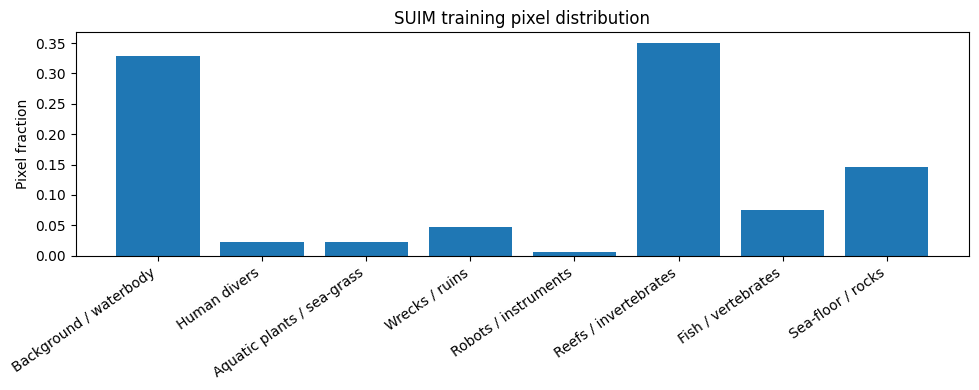

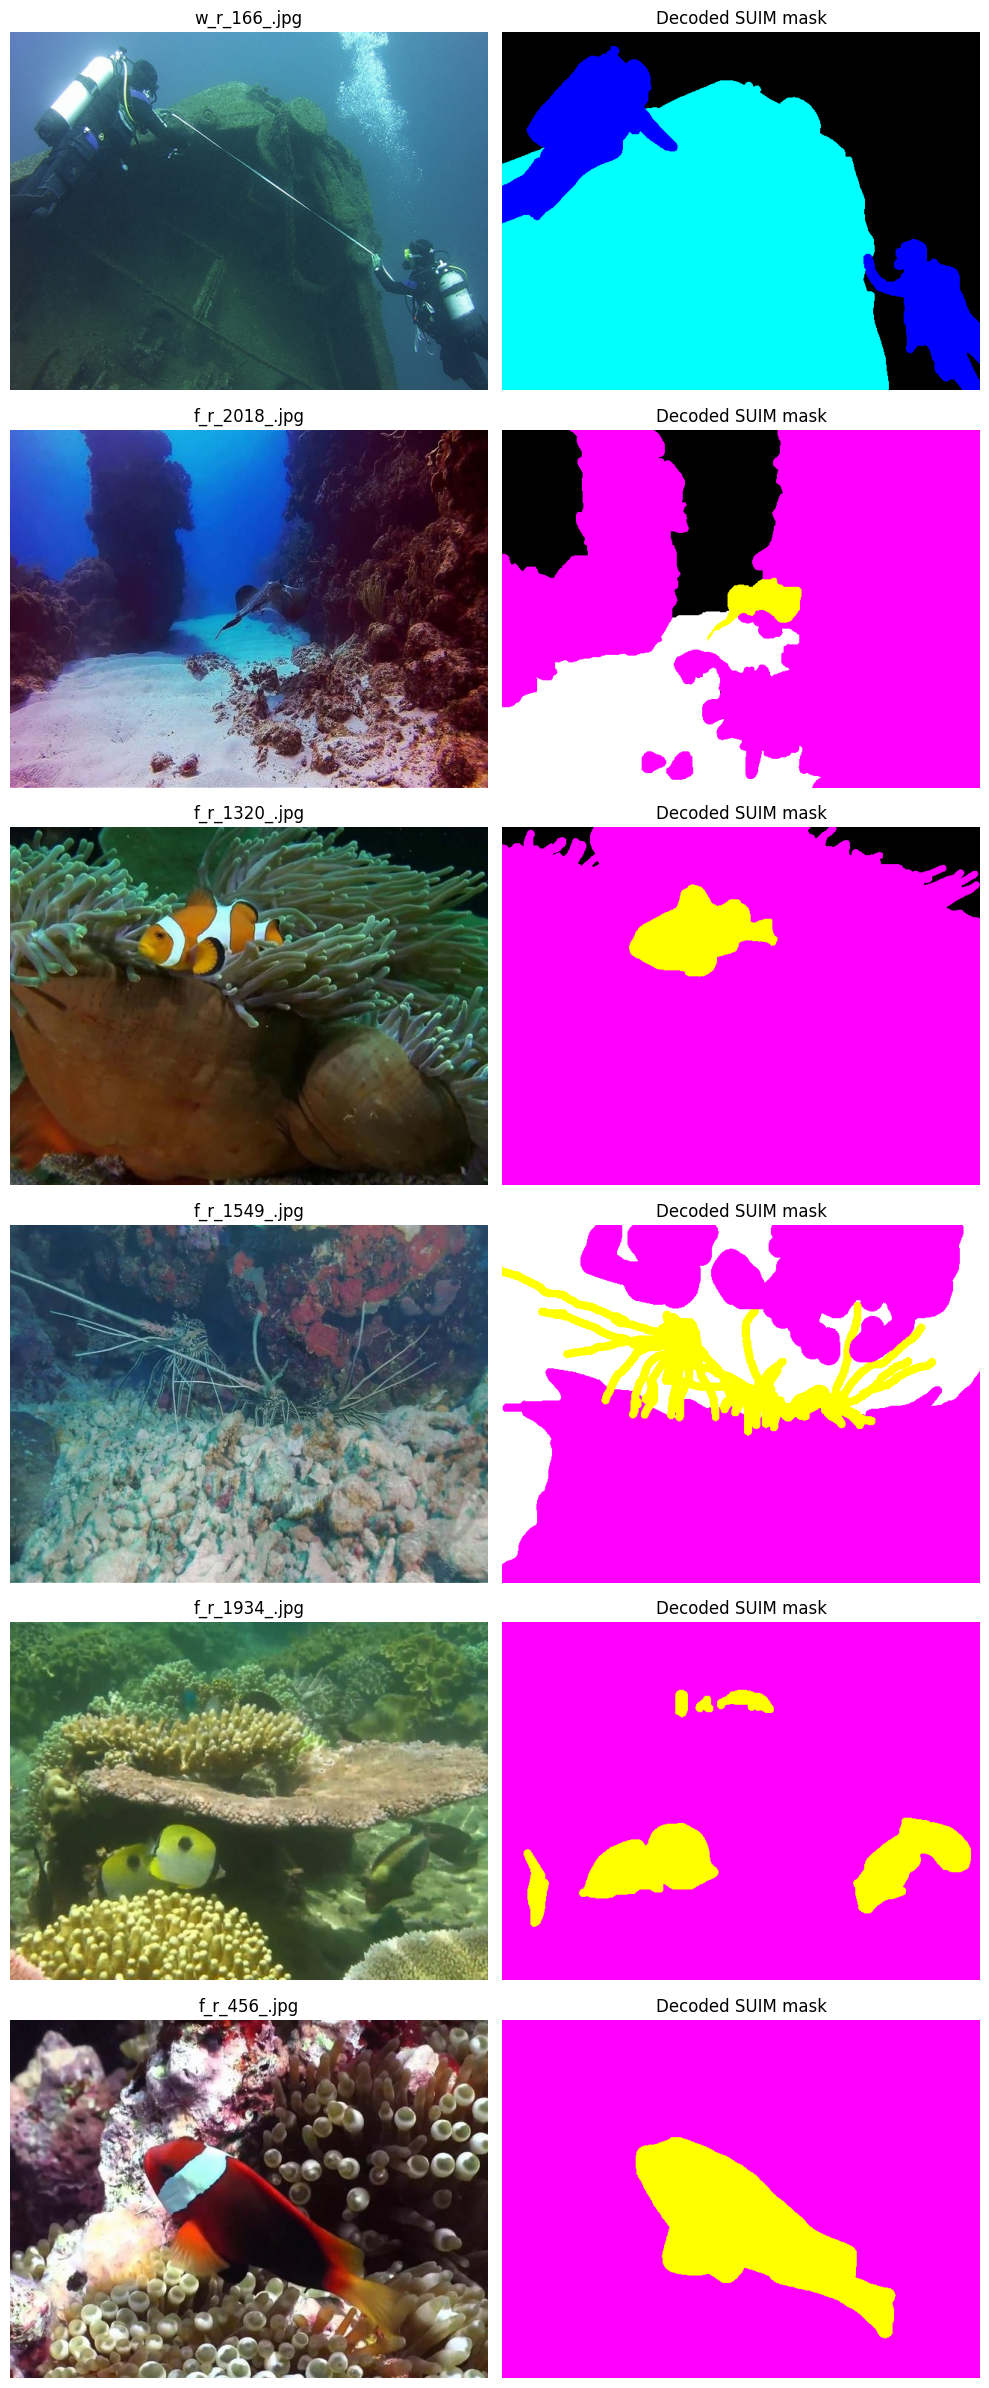

In [54]:
# ================================================================
# Cell 4: Mask decoding, color analysis, and class weights
# ================================================================

def mask_to_class_ids(mask: np.ndarray) -> np.ndarray:
    if mask.ndim == 2:
        values = np.unique(mask)
        valid_values = set(range(NUM_CLASSES))
        if set(values.tolist()).issubset(valid_values):
            return mask.astype(np.int64)
        raise ValueError(f"Unexpected grayscale mask values: {values[:20].tolist()}")

    if mask.ndim != 3 or mask.shape[-1] != 3:
        raise ValueError(f"Expected a 3-channel RGB mask, got shape {mask.shape}")

    flat = mask.reshape(-1, 3)
    out = np.full((flat.shape[0],), -1, dtype=np.int16)

    for rgb, class_id in RGB_TO_CLASS.items():
        rgb_array = np.array(rgb, dtype=np.uint8)
        matches = np.all(flat == rgb_array, axis=1)
        out[matches] = class_id

    unresolved = out < 0
    if np.any(unresolved):
        unresolved_pixels = flat[unresolved]
        grayscale_pixels = (
            (unresolved_pixels[:, 0] == unresolved_pixels[:, 1])
            & (unresolved_pixels[:, 1] == unresolved_pixels[:, 2])
        )
        compact_values = unresolved_pixels[:, 0]
        compact_valid = grayscale_pixels & (compact_values < NUM_CLASSES)
        unresolved_indices = np.flatnonzero(unresolved)
        valid_indices = unresolved_indices[compact_valid]
        out[valid_indices] = compact_values[compact_valid].astype(np.int16)

    if np.any(out < 0):
        unknown = np.unique(flat[out < 0], axis=0)
        raise ValueError(f"Unknown mask colors found: {unknown[:20].tolist()}")

    return out.reshape(mask.shape[:2]).astype(np.int64)


def analyze_mask_colors(pairs, max_samples=None):
    counts = np.zeros(NUM_CLASSES, dtype=np.int64)
    color_counter = Counter()
    selected = pairs if max_samples is None else pairs[:max_samples]

    from tqdm.auto import tqdm
    for _, mask_path in tqdm(selected, total=len(selected), desc="Analyzing SUIM masks", unit="mask", dynamic_ncols=True):
        arr = np.array(Image.open(mask_path).convert("RGB"))
        class_ids = mask_to_class_ids(arr)
        vals, freqs = np.unique(class_ids, return_counts=True)
        counts[vals] += freqs

        colors = arr.reshape(-1, 3)
        for row in np.unique(colors, axis=0):
            color_counter[tuple(row.tolist())] += int(np.all(colors == row, axis=1).sum())

    return counts, color_counter


train_pixel_counts, train_colors = analyze_mask_colors(train_pairs)

print("Observed training mask colors:")
for color, n in train_colors.most_common(12):
    print(color, n)

class_freq_df = pd.DataFrame({
    "class_id": np.arange(NUM_CLASSES),
    "class": CLASS_NAMES,
    "pixels": train_pixel_counts,
})
class_freq_df["fraction"] = class_freq_df["pixels"] / class_freq_df["pixels"].sum()

# ---------------------------------------------------------------
# Compute smoothed inverse-frequency class weights
# Formula: w_c = 1.0 / (sqrt(fraction_c) + 0.05)
# ---------------------------------------------------------------
fractions = class_freq_df["fraction"].to_numpy()
raw_weights = 1.0 / (np.sqrt(fractions) + 0.05)
normalized_weights = raw_weights / raw_weights.mean()
class_freq_df["loss_weight"] = normalized_weights

CLASS_WEIGHTS_TENSOR = torch.tensor(normalized_weights, dtype=torch.float32).to(DEVICE)
print("\nComputed Class Loss Weights for Imbalance Mitigation:")
display(class_freq_df)

fig = plt.figure(figsize=(10, 4))
plt.bar(class_freq_df["class"], class_freq_df["fraction"])
plt.xticks(rotation=35, ha="right")
plt.ylabel("Pixel fraction")
plt.title("SUIM training pixel distribution")
plt.tight_layout()
fig.savefig(OUTPUT_ROOT / "figures" / "dataset_class_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

rng = np.random.default_rng(SEED)
show_pairs = [train_pairs[i] for i in rng.choice(len(train_pairs), size=min(6, len(train_pairs)), replace=False)]

fig, axes = plt.subplots(len(show_pairs), 2, figsize=(10, 4 * len(show_pairs)))
if len(show_pairs) == 1:
    axes = np.array([axes])
for row, (img_path, mask_path) in enumerate(show_pairs):
    image = np.array(Image.open(img_path).convert("RGB"))
    mask_rgb = np.array(Image.open(mask_path).convert("RGB"))
    mask_ids = mask_to_class_ids(mask_rgb)
    color_mask = CLASS_RGB[mask_ids]
    axes[row, 0].imshow(image)
    axes[row, 0].set_title(img_path.name)
    axes[row, 1].imshow(color_mask)
    axes[row, 1].set_title("Decoded SUIM mask")
    axes[row, 0].axis("off")
    axes[row, 1].axis("off")
plt.tight_layout()
fig.savefig(OUTPUT_ROOT / "figures" / "dataset_samples.png", dpi=180, bbox_inches="tight")
plt.show()

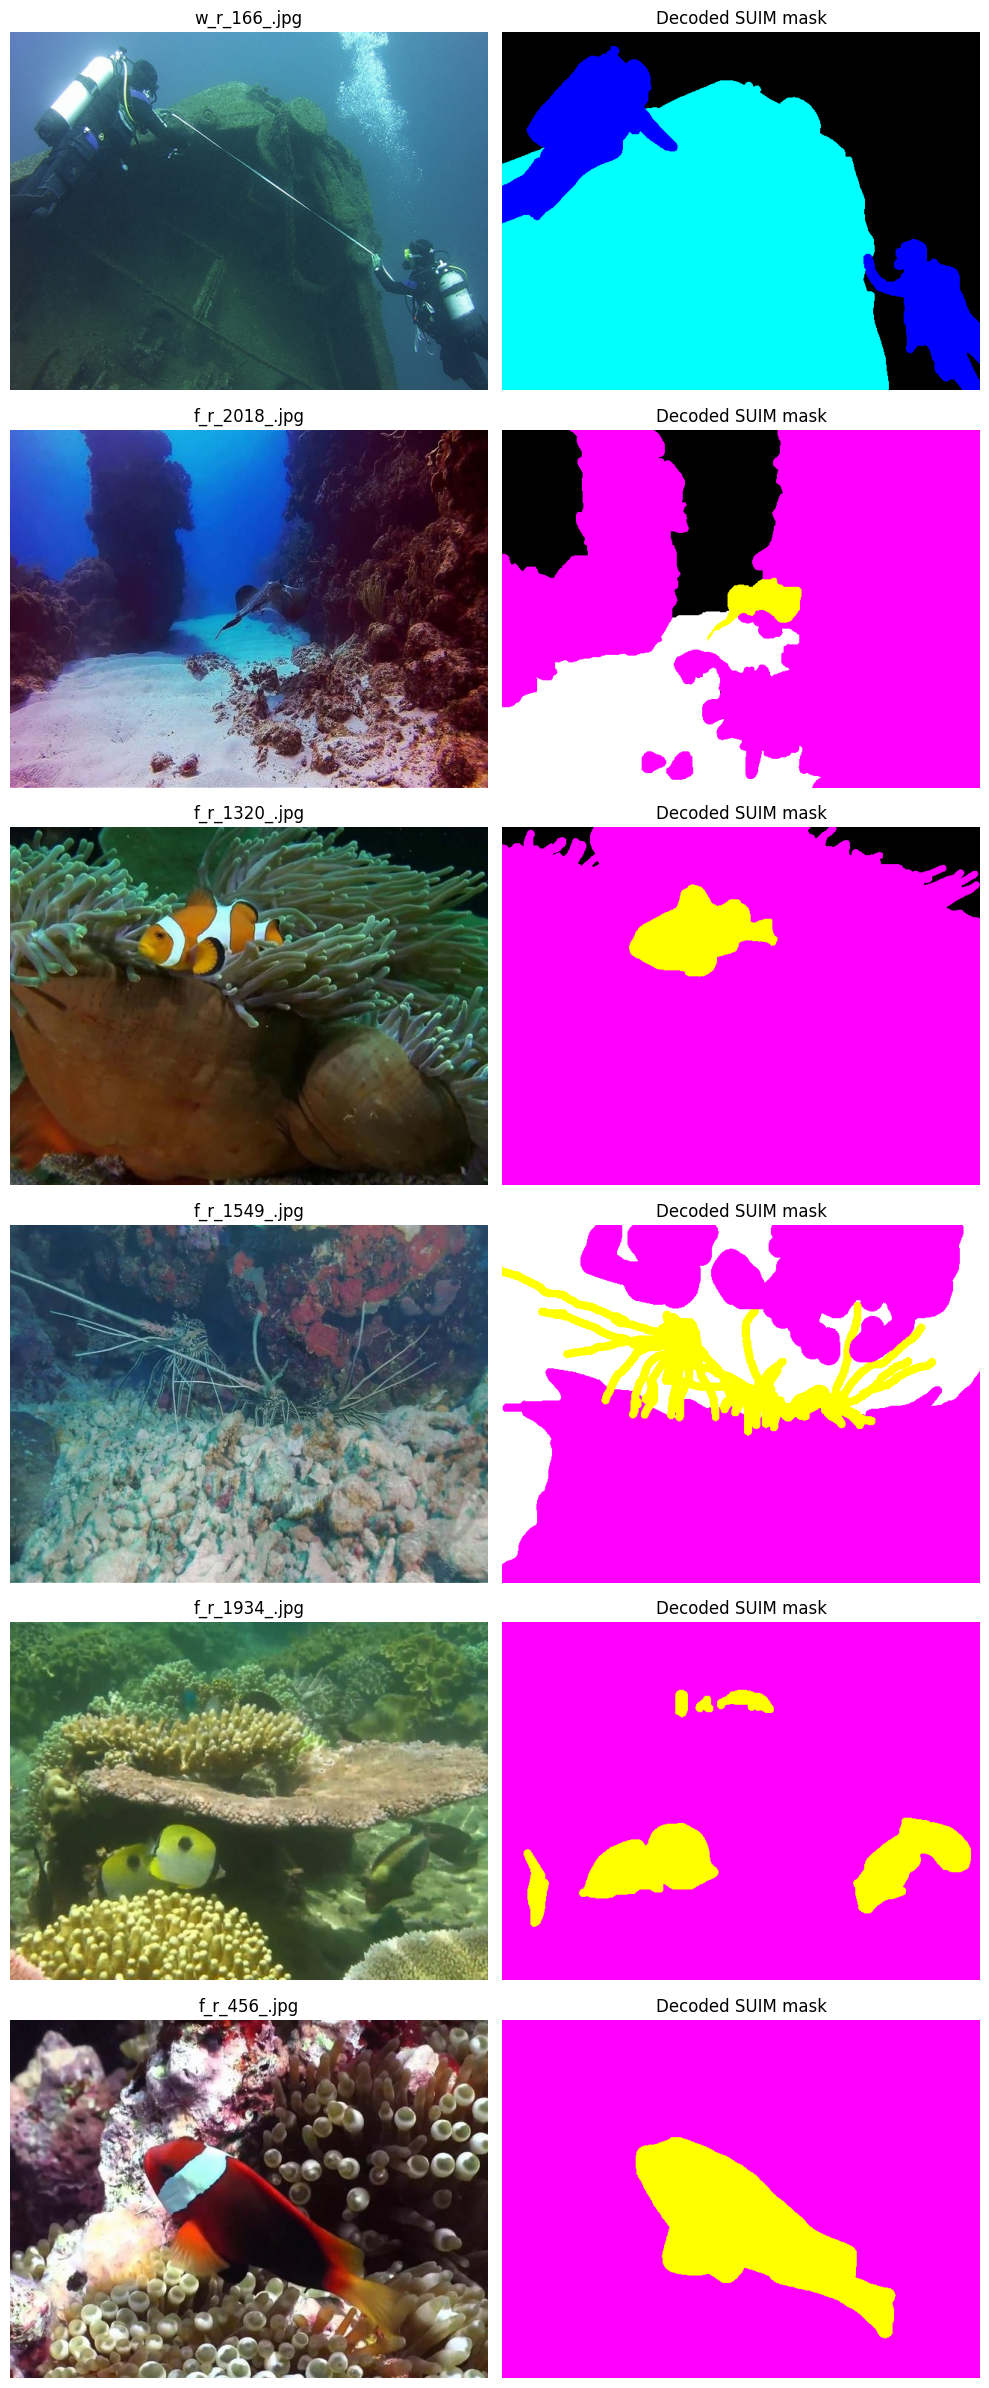

In [55]:
# Show a few raw images with their decoded class masks.
rng = np.random.default_rng(SEED)
show_pairs = [train_pairs[i] for i in rng.choice(len(train_pairs), size=min(6, len(train_pairs)), replace=False)]

fig, axes = plt.subplots(len(show_pairs), 2, figsize=(10, 4 * len(show_pairs)))
if len(show_pairs) == 1:
    axes = np.array([axes])
for row, (img_path, mask_path) in enumerate(show_pairs):
    image = np.array(Image.open(img_path).convert("RGB"))
    mask_rgb = np.array(Image.open(mask_path).convert("RGB"))
    mask_ids = mask_to_class_ids(mask_rgb)
    color_mask = CLASS_RGB[mask_ids]
    axes[row, 0].imshow(image)
    axes[row, 0].set_title(img_path.name)
    axes[row, 1].imshow(color_mask)
    axes[row, 1].set_title("Decoded SUIM mask")
    axes[row, 0].axis("off")
    axes[row, 1].axis("off")
plt.tight_layout()
fig.savefig(OUTPUT_ROOT / "figures" / "dataset_samples.png", dpi=180, bbox_inches="tight")
plt.show()

## 3. Deterministic Train/Validation Split

The official 110-image `TEST` split is never used for training or calibration. The 1,525-image `train_val` pool is split into training and validation subsets using a fixed seed. The stratification label is the dominant non-background class in each image; this is not a substitute for multilabel stratification, but it helps reduce severe split skew while keeping the implementation simple and deterministic.


In [56]:
def dominant_foreground_label(mask_path: Path) -> int:
    arr = np.array(Image.open(mask_path).convert("RGB"))
    ids = mask_to_class_ids(arr)
    counts = np.bincount(ids.ravel(), minlength=NUM_CLASSES)
    counts[0] = 0
    return int(counts.argmax()) if counts.sum() > 0 else 0

all_indices = np.arange(len(train_pairs))
dominant_labels = np.array([dominant_foreground_label(mask) for _, mask in train_pairs])

try:
    train_idx, val_idx = train_test_split(
        all_indices,
        test_size=VAL_FRACTION,
        random_state=SEED,
        stratify=dominant_labels if len(np.unique(dominant_labels)) > 1 else None,
    )
except ValueError as exc:
    print(f"Stratified split was not feasible: {exc}")
    print("Falling back to a deterministic unstratified split.")
    train_idx, val_idx = train_test_split(
        all_indices, test_size=VAL_FRACTION, random_state=SEED, stratify=None
    )

train_split = [train_pairs[i] for i in sorted(train_idx)]
val_split = [train_pairs[i] for i in sorted(val_idx)]

print("Training images:", len(train_split))
print("Validation images:", len(val_split))
print("Held-out test images:", len(test_pairs))
assert set(train_idx).isdisjoint(set(val_idx))

Training images: 1283
Validation images: 227
Held-out test images: 110


## 4. Data Preprocessing and Augmentation

All inputs are resized to `256×256` to keep the Colab workload practical. Geometric transforms are applied the same way to the image and mask, while photometric transforms are applied only to the image. Mask interpolation always uses nearest-neighbor, so class IDs are not averaged accidentally.


In [57]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

class SUIMDataset(Dataset):
    def __init__(self, pairs, train=False, image_size=256):
        self.pairs = list(pairs)
        self.train = train
        self.image_size = int(image_size)
        self.color_jitter = transforms.ColorJitter(
            brightness=0.18, contrast=0.18, saturation=0.15, hue=0.03
        )

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, index):
        image_path, mask_path = self.pairs[index]
        image = Image.open(image_path).convert("RGB")
        mask_rgb = Image.open(mask_path).convert("RGB")

        image = TF.resize(image, [self.image_size, self.image_size], interpolation=transforms.InterpolationMode.BILINEAR)
        mask_rgb = TF.resize(mask_rgb, [self.image_size, self.image_size], interpolation=transforms.InterpolationMode.NEAREST)

        if self.train:
            if random.random() < 0.5:
                image = TF.hflip(image)
                mask_rgb = TF.hflip(mask_rgb)

            if random.random() < 0.35:
                angle = random.uniform(-8.0, 8.0)
                image = TF.rotate(image, angle, interpolation=transforms.InterpolationMode.BILINEAR, fill=0)
                mask_rgb = TF.rotate(mask_rgb, angle, interpolation=transforms.InterpolationMode.NEAREST, fill=0)

            image = self.color_jitter(image)

        image_np = np.array(image)
        mask_np = np.array(mask_rgb)
        mask_ids = mask_to_class_ids(mask_np)

        image_tensor = TF.to_tensor(image)
        image_tensor = TF.normalize(image_tensor, IMAGENET_MEAN, IMAGENET_STD)
        mask_tensor = torch.from_numpy(mask_ids).long()
        return image_tensor, mask_tensor, str(image_path), str(mask_path)

train_dataset = SUIMDataset(train_split, train=True, image_size=IMAGE_SIZE)
val_dataset = SUIMDataset(val_split, train=False, image_size=IMAGE_SIZE)
test_dataset = SUIMDataset(test_pairs, train=False, image_size=IMAGE_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, drop_last=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

xb, yb, _, _ = next(iter(train_loader))
print("Image batch shape:", tuple(xb.shape))
print("Mask batch shape :", tuple(yb.shape))
print("Mask dtype       :", yb.dtype)
assert xb.shape[-2:] == (IMAGE_SIZE, IMAGE_SIZE)
assert yb.shape[-2:] == (IMAGE_SIZE, IMAGE_SIZE)
assert yb.min().item() >= 0 and yb.max().item() < NUM_CLASSES

Image batch shape: (8, 3, 256, 256)
Mask batch shape : (8, 256, 256)
Mask dtype       : torch.int64


## 5. Model Definition

**Why DeepLabV3 + MobileNetV3-Large?** TorchVision provides a maintained implementation and pretrained ImageNet backbone weights, while MobileNetV3 is much lighter than a ResNet-50/101 alternative. The DeepLab head adds multiscale context through atrous convolutions, which is useful when underwater objects appear at different apparent scales.

A small `Dropout2d` layer is added immediately before the final segmentation classifier. This keeps the uncertainty mechanism explicit and easy to inspect. It is an **approximate Bayesian inference device**, not a claim of exact posterior inference.


In [58]:
def build_model(dropout_p=0.20):
    pretrained_backbone = True
    try:
        model = deeplabv3_mobilenet_v3_large(
            weights=None,
            weights_backbone=MobileNet_V3_Large_Weights.DEFAULT,
            num_classes=NUM_CLASSES,
            aux_loss=True,
        )
    except Exception as exc:
        pretrained_backbone = False
        print(f"Pretrained MobileNetV3 weights were unavailable: {exc}")
        print("Falling back to random backbone initialization so the notebook can still run.")
        model = deeplabv3_mobilenet_v3_large(
            weights=None,
            weights_backbone=None,
            num_classes=NUM_CLASSES,
            aux_loss=True,
        )
    model._pretrained_backbone = pretrained_backbone

    # Add a stochastic layer before the final pixel classifier.
    if isinstance(model.classifier, nn.Sequential):
        layers = list(model.classifier.children())
        final_layer = layers.pop()
        model.classifier = nn.Sequential(*layers, nn.Dropout2d(p=dropout_p), final_layer)

    if getattr(model, "aux_classifier", None) is not None and isinstance(model.aux_classifier, nn.Sequential):
        layers = list(model.aux_classifier.children())
        final_layer = layers.pop()
        model.aux_classifier = nn.Sequential(*layers, nn.Dropout2d(p=dropout_p), final_layer)

    return model.to(DEVICE)

model_probe = build_model()
num_params = sum(p.numel() for p in model_probe.parameters())
trainable_params = sum(p.numel() for p in model_probe.parameters() if p.requires_grad)
print(f"Total parameters: {num_params / 1e6:.2f} M")
print(f"Trainable parameters: {trainable_params / 1e6:.2f} M")
model_probe.eval() # Put the model in evaluation mode for probing.
with torch.no_grad():
    out = model_probe(xb[:1].to(DEVICE))
print("Output keys:", out.keys())
print("Main logits shape:", tuple(out["out"].shape))
del model_probe, out
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Total parameters: 11.03 M
Trainable parameters: 11.03 M
Output keys: odict_keys(['out', 'aux'])
Main logits shape: (1, 8, 256, 256)


## 6. Loss Functions

The primary objective is:

\[
\mathcal{L}=\mathcal{L}_{CE}+\lambda_{Dice}\mathcal{L}_{Dice}+\lambda_{aux}\mathcal{L}_{aux}.
\]

The Dice term is computed from softmax probabilities and one-hot targets, then averaged over classes. This gives a class-balanced overlap signal that complements pixel-wise cross-entropy. The auxiliary head is trained with cross-entropy only and is discarded at inference.


In [59]:
# ================================================================
# Cell 8: Weighted loss functions (weighted CE + multi-class Dice)
# ================================================================

def soft_dice_loss(logits, targets, smooth=1.0):
    probs = torch.softmax(logits, dim=1)
    one_hot = F.one_hot(targets, num_classes=NUM_CLASSES).permute(0, 3, 1, 2).float()
    dims = (0, 2, 3)
    intersection = (probs * one_hot).sum(dims)
    denominator = probs.sum(dims) + one_hot.sum(dims)
    dice = (2.0 * intersection + smooth) / (denominator + smooth)
    return 1.0 - dice.mean()


def segmentation_loss(
    outputs,
    targets,
    mode="ce_dice",
    ce_weight=1.0,
    dice_weight=DICE_WEIGHT,
    aux_weight=AUX_WEIGHT,
    class_weights=None
):
    # Use class weights to reduce the effect of severe class imbalance.
    if class_weights is None and "CLASS_WEIGHTS_TENSOR" in globals():
        class_weights = CLASS_WEIGHTS_TENSOR

    ce = F.cross_entropy(outputs["out"], targets, weight=class_weights)
    dice = soft_dice_loss(outputs["out"], targets)

    if mode == "ce_only":
        main_loss = ce
    elif mode == "ce_dice":
        main_loss = ce_weight * ce + dice_weight * dice
    else:
        raise ValueError(f"Unknown loss mode: {mode}")

    if "aux" in outputs:
        aux_loss = F.cross_entropy(outputs["aux"], targets, weight=class_weights)
        total = main_loss + aux_weight * aux_loss
    else:
        aux_loss = torch.zeros((), device=targets.device)
        total = main_loss

    return total, {
        "ce": ce.detach().item(),
        "dice_loss": dice.detach().item(),
        "aux_ce": aux_loss.detach().item()
    }

# Run a quick shape and loss check.
test_model = build_model()
test_model.eval()
with torch.no_grad():
    test_out = test_model(xb[:2].to(DEVICE))
    test_loss, pieces = segmentation_loss(test_out, yb[:2].to(DEVICE), mode="ce_dice", class_weights=CLASS_WEIGHTS_TENSOR)
print("Loss shape test:", float(test_loss), pieces)
assert test_out["out"].shape == (2, NUM_CLASSES, IMAGE_SIZE, IMAGE_SIZE)
del test_model, test_out
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Loss shape test: 3.726738452911377 {'ce': 2.0919651985168457, 'dice_loss': 0.9329398274421692, 'aux_ce': 2.9207582473754883}


## 7. Metrics and Calibration Utilities

For segmentation quality, the notebook computes pixel accuracy, per-class IoU, mean IoU, per-class Dice, and mean Dice from an accumulated confusion matrix.

For uncertainty/calibration, it computes pixel-level ECE, reliability curves, confidence/error statistics, risk-coverage curves, and an AURC-like trapezoidal summary. For semantic segmentation, these metrics are calculated over **pixels**, not whole images.


In [60]:
def update_confusion_matrix(cm, preds, targets, num_classes):
    preds = preds.reshape(-1).detach().cpu().numpy()
    targets = targets.reshape(-1).detach().cpu().numpy()
    valid = (targets >= 0) & (targets < num_classes)
    indices = num_classes * targets[valid] + preds[valid]
    cm += np.bincount(indices, minlength=num_classes ** 2).reshape(num_classes, num_classes)
    return cm


def metrics_from_confusion(cm):
    tp = np.diag(cm).astype(np.float64)
    fp = cm.sum(axis=0) - tp
    fn = cm.sum(axis=1) - tp
    union = tp + fp + fn
    iou = np.divide(tp, union, out=np.zeros_like(tp), where=union > 0)
    dice = np.divide(2 * tp, 2 * tp + fp + fn, out=np.zeros_like(tp), where=(2 * tp + fp + fn) > 0)
    accuracy = tp.sum() / max(cm.sum(), 1)
    valid = union > 0
    return {
        "pixel_accuracy": float(accuracy),
        "miou": float(iou[valid].mean()),
        "mean_dice": float(dice[valid].mean()),
        "per_class_iou": iou,
        "per_class_dice": dice,
        "confusion_matrix": cm.copy(),
    }


def expected_calibration_error(confidence, correct, n_bins=15):
    confidence = np.asarray(confidence, dtype=np.float64)
    correct = np.asarray(correct, dtype=np.float64)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    rows = []
    total = len(confidence)
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        if i == n_bins - 1:
            sel = (confidence >= lo) & (confidence <= hi)
        else:
            sel = (confidence >= lo) & (confidence < hi)
        n = int(sel.sum())
        if n == 0:
            continue
        acc = float(correct[sel].mean())
        conf = float(confidence[sel].mean())
        frac = n / max(total, 1)
        ece += frac * abs(acc - conf)
        rows.append({"bin": i, "count": n, "mean_confidence": conf, "accuracy": acc, "gap": acc - conf})
    return float(ece), pd.DataFrame(rows)


def risk_coverage(confidence, correct):
    confidence = np.asarray(confidence)
    correct = np.asarray(correct).astype(np.float64)
    order = np.argsort(-confidence)
    errors = 1.0 - correct[order]
    cumulative_risk = np.cumsum(errors) / np.arange(1, len(errors) + 1)
    coverage = np.arange(1, len(errors) + 1) / len(errors)
    aurc = float(np.trapezoid(cumulative_risk, coverage)) if hasattr(np, "trapezoid") else float(np.trapz(cumulative_risk, coverage))
    return coverage, cumulative_risk, aurc

## 8. Training and Evaluation Utilities

The training loop uses AdamW, AMP on CUDA, gradient clipping, checkpointing, and early stopping based on validation mIoU. Every experiment records its full configuration and history in JSON/CSV files.


In [61]:
# ================================================================
# Cell 10: Training loop and evaluation utilities
# ================================================================

def save_json(obj, path: Path):
    serializable = {}
    for k, v in obj.items():
        if isinstance(v, (np.integer, np.floating)):
            serializable[k] = v.item()
        elif isinstance(v, Path):
            serializable[k] = str(v)
        else:
            serializable[k] = v
    path.write_text(json.dumps(serializable, indent=2, default=str))


def run_epoch(model, loader, optimizer=None, loss_mode="ce_dice", scaler=None, class_weights=None):
    training = optimizer is not None
    model.train(training)
    if not training:
        model.eval()

    cm = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)
    loss_sum = 0.0
    n_batches = 0
    ce_sum = dice_sum = aux_sum = 0.0

    for images, targets, _, _ in loader:
        images = images.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True)
        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=AMP_ENABLED):
            outputs = model(images)
            loss, pieces = segmentation_loss(
                outputs,
                targets,
                mode=loss_mode,
                class_weights=class_weights
            )

        if training:
            if scaler is not None and AMP_ENABLED:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        preds = outputs["out"].argmax(dim=1)
        cm = update_confusion_matrix(cm, preds, targets, NUM_CLASSES)
        loss_sum += float(loss.detach().item())
        ce_sum += pieces["ce"]
        dice_sum += pieces["dice_loss"]
        aux_sum += pieces["aux_ce"]
        n_batches += 1

    metrics = metrics_from_confusion(cm)
    metrics.update({
        "loss": loss_sum / max(n_batches, 1),
        "ce": ce_sum / max(n_batches, 1),
        "dice_loss": dice_sum / max(n_batches, 1),
        "aux_ce": aux_sum / max(n_batches, 1),
    })
    return metrics


def train_experiment(exp_id, loss_mode, learning_rate, epochs=EPOCHS):
    seed_everything(stable_seed(SEED, exp_id))
    model = build_model(dropout_p=0.20)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=WEIGHT_DECAY)

    # Use eta_min for a smoother cosine decay near the end of training.
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

    if hasattr(torch, "amp") and hasattr(torch.amp, "GradScaler"):
        scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
    else:
        scaler = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)

    ckpt_path = OUTPUT_ROOT / "checkpoints" / f"{exp_id}_best.pt"
    history = []
    best_miou = -np.inf
    bad_epochs = 0
    start = time.perf_counter()

    weights_to_use = CLASS_WEIGHTS_TENSOR if loss_mode == "ce_dice" else None

    for epoch in range(1, epochs + 1):
        train_metrics = run_epoch(
            model, train_loader, optimizer=optimizer, loss_mode=loss_mode, scaler=scaler, class_weights=weights_to_use
        )
        val_metrics = run_epoch(
            model, val_loader, optimizer=None, loss_mode=loss_mode, scaler=None, class_weights=weights_to_use
        )
        scheduler.step()
        elapsed = time.perf_counter() - start
        row = {
            "experiment": exp_id,
            "epoch": epoch,
            "lr": optimizer.param_groups[0]["lr"],
            "train_loss": train_metrics["loss"],
            "val_loss": val_metrics["loss"],
            "train_miou": train_metrics["miou"],
            "val_miou": val_metrics["miou"],
            "train_dice": train_metrics["mean_dice"],
            "val_dice": val_metrics["mean_dice"],
            "elapsed_sec": elapsed,
        }
        history.append(row)
        print(
            f"{exp_id} | epoch {epoch:02d}/{epochs} | "
            f"train mIoU={train_metrics['miou']:.4f} | val mIoU={val_metrics['miou']:.4f} | "
            f"val Dice={val_metrics['mean_dice']:.4f} | {elapsed:.1f}s"
        )

        if val_metrics["miou"] > best_miou:
            best_miou = val_metrics["miou"]
            bad_epochs = 0
            torch.save({
                "model_state": model.state_dict(),
                "experiment": exp_id,
                "loss_mode": loss_mode,
                "learning_rate": learning_rate,
                "epoch": epoch,
                "val_miou": best_miou,
                "seed": stable_seed(SEED, exp_id),
                "image_size": IMAGE_SIZE,
                "num_classes": NUM_CLASSES,
            }, ckpt_path)
        else:
            bad_epochs += 1
            if bad_epochs >= EARLY_STOPPING_PATIENCE:
                print(f"Early stopping triggered at epoch {epoch}.")
                break

    history_df = pd.DataFrame(history)
    history_df.to_csv(OUTPUT_ROOT / "metrics" / f"{exp_id}_training_history.csv", index=False)
    config = {
        "experiment": exp_id,
        "loss_mode": loss_mode,
        "learning_rate": learning_rate,
        "weight_decay": WEIGHT_DECAY,
        "image_size": IMAGE_SIZE,
        "batch_size": BATCH_SIZE,
        "epochs_requested": epochs,
        "dropout_p": 0.20,
        "pretrained_backbone": bool(getattr(model, "_pretrained_backbone", True)),
        "aux_weight": AUX_WEIGHT,
        "seed": stable_seed(SEED, exp_id),
        "device": str(DEVICE),
    }
    save_json(config, OUTPUT_ROOT / "configs" / f"{exp_id}.json")
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return ckpt_path, history_df


def load_checkpoint(ckpt_path):
    checkpoint = torch.load(ckpt_path, map_location=DEVICE)
    model = build_model(dropout_p=0.20)
    model.load_state_dict(checkpoint["model_state"])
    return model, checkpoint

## 9. Baseline Experiment

The baseline uses **Cross-Entropy + Dice**. This is the main model used for the uncertainty and calibration analysis.


In [82]:
experiments = [
    {"id": "experiment_01_baseline_ce_dice", "loss_mode": "ce_dice", "lr": LEARNING_RATE},
    {"id": "experiment_02_ablation_ce_only", "loss_mode": "ce_only", "lr": LEARNING_RATE},
]

if SMOKE_TEST:
    run_epochs = 1
else:
    run_epochs = EPOCHS

experiment_checkpoints = {}
experiment_histories = {}
for exp in experiments:
    ckpt, hist = train_experiment(exp["id"], exp["loss_mode"], exp["lr"], epochs=run_epochs)
    experiment_checkpoints[exp["id"]] = ckpt
    experiment_histories[exp["id"]] = hist

experiment_01_baseline_ce_dice | epoch 01/25 | train mIoU=0.3392 | val mIoU=0.4783 | val Dice=0.6232 | 52.6s
experiment_01_baseline_ce_dice | epoch 02/25 | train mIoU=0.4649 | val mIoU=0.4512 | val Dice=0.6007 | 99.8s
experiment_01_baseline_ce_dice | epoch 03/25 | train mIoU=0.5134 | val mIoU=0.4773 | val Dice=0.6228 | 145.9s
experiment_01_baseline_ce_dice | epoch 04/25 | train mIoU=0.5565 | val mIoU=0.5130 | val Dice=0.6529 | 190.8s
experiment_01_baseline_ce_dice | epoch 05/25 | train mIoU=0.5922 | val mIoU=0.5540 | val Dice=0.6939 | 237.6s
experiment_01_baseline_ce_dice | epoch 06/25 | train mIoU=0.6082 | val mIoU=0.5490 | val Dice=0.6929 | 282.6s
experiment_01_baseline_ce_dice | epoch 07/25 | train mIoU=0.6404 | val mIoU=0.5211 | val Dice=0.6678 | 327.7s
experiment_01_baseline_ce_dice | epoch 08/25 | train mIoU=0.6593 | val mIoU=0.5431 | val Dice=0.6845 | 372.4s
experiment_01_baseline_ce_dice | epoch 09/25 | train mIoU=0.6750 | val mIoU=0.5378 | val Dice=0.6825 | 418.9s
experiment_0

## 10. Training Curves

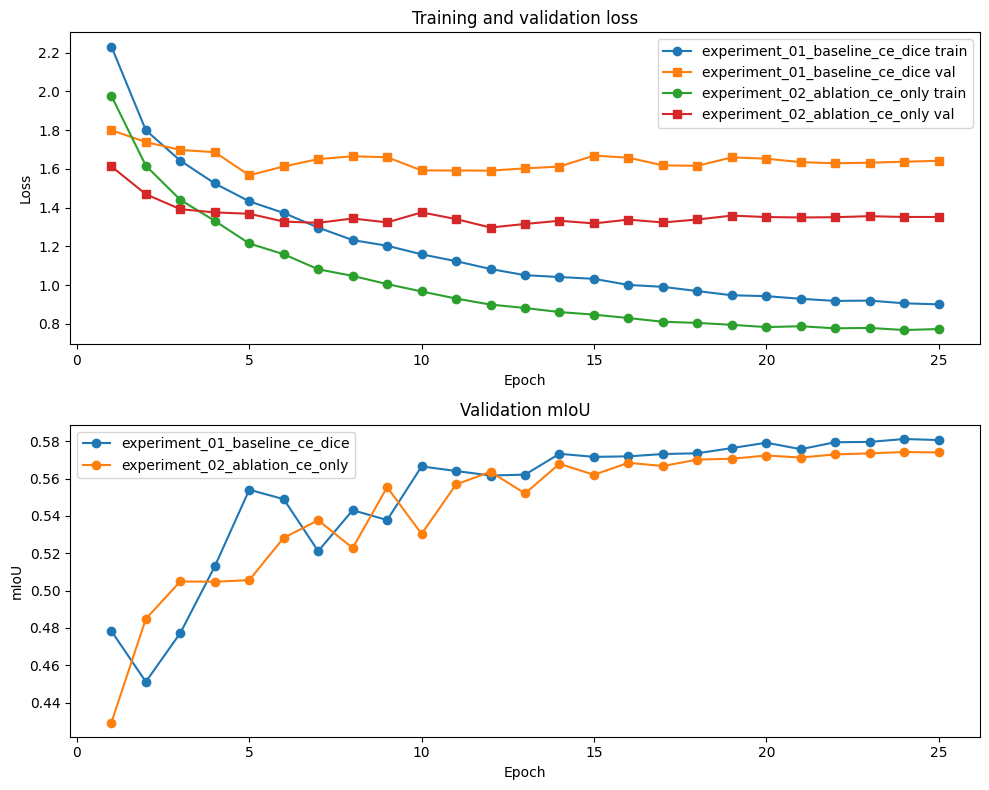

In [83]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=False)
for exp_id, hist in experiment_histories.items():
    axes[0].plot(hist["epoch"], hist["train_loss"], marker="o", label=f"{exp_id} train")
    axes[0].plot(hist["epoch"], hist["val_loss"], marker="s", label=f"{exp_id} val")
    axes[1].plot(hist["epoch"], hist["val_miou"], marker="o", label=exp_id)
axes[0].set_title("Training and validation loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[1].set_title("Validation mIoU")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("mIoU")
axes[1].legend()
plt.tight_layout()
fig.savefig(OUTPUT_ROOT / "figures" / "training_curves.png", dpi=180, bbox_inches="tight")
plt.show()

## 11. Quantitative Evaluation on the Held-Out SUIM Test Set

Only the checkpoint selected from the training/validation split is evaluated on the 110-image test set. This keeps test labels out of model selection, temperature fitting, and MC-sample tuning.


In [84]:
def evaluate_deterministic(model, loader, collect_probabilities=False, max_pixels=None):
    model.eval()
    cm = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)
    confidence_parts, correct_parts = [], []
    logits_parts, target_parts = [], []
    sample_records = []

    total_time = 0.0
    with torch.no_grad():
        for images, targets, image_paths, mask_paths in loader:
            images = images.to(DEVICE, non_blocking=True)
            targets = targets.to(DEVICE, non_blocking=True)
            if DEVICE.type == "cuda":
                torch.cuda.synchronize()
            start = time.perf_counter()
            with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=AMP_ENABLED):
                logits = model(images)["out"]
            if DEVICE.type == "cuda":
                torch.cuda.synchronize()
            total_time += time.perf_counter() - start

            probs = torch.softmax(logits.float(), dim=1)
            conf, pred = probs.max(dim=1)
            correct = pred.eq(targets)
            cm = update_confusion_matrix(cm, pred, targets, NUM_CLASSES)
            confidence_parts.append(conf.reshape(-1).cpu().numpy())
            correct_parts.append(correct.reshape(-1).cpu().numpy().astype(np.float32))

            if collect_probabilities:
                flat_logits = logits.float().permute(0, 2, 3, 1).reshape(-1, NUM_CLASSES).cpu()
                flat_targets = targets.reshape(-1).cpu()
                logits_parts.append(flat_logits)
                target_parts.append(flat_targets)

            for i, path in enumerate(image_paths):
                sample_records.append({"image_path": path, "mask_path": mask_paths[i]})

    metrics = metrics_from_confusion(cm)
    confidence = np.concatenate(confidence_parts)
    correct = np.concatenate(correct_parts)
    metrics["ece"] = expected_calibration_error(confidence, correct)[0]
    metrics["aurc"] = risk_coverage(confidence, correct)[2]
    metrics["mean_confidence"] = float(confidence.mean())
    metrics["accuracy_on_confidence_top_half"] = float(correct[confidence >= np.median(confidence)].mean())
    metrics["mean_inference_sec"] = total_time / max(len(loader.dataset), 1)
    if collect_probabilities:
        all_logits = torch.cat(logits_parts, dim=0)
        all_targets = torch.cat(target_parts, dim=0)
        if max_pixels is not None and len(all_targets) > max_pixels:
            g = torch.Generator().manual_seed(SEED + 99)
            idx = torch.randperm(len(all_targets), generator=g)[:max_pixels]
            all_logits = all_logits[idx]
            all_targets = all_targets[idx]
        metrics["calibration_logits"] = all_logits
        metrics["calibration_targets"] = all_targets
    return metrics, confidence, correct, sample_records


baseline_model, baseline_ckpt = load_checkpoint(experiment_checkpoints["experiment_01_baseline_ce_dice"])

all_eval_metrics = []
for exp_id, ckpt_path in experiment_checkpoints.items():
    model, checkpoint = load_checkpoint(ckpt_path)
    metrics, conf, corr, _ = evaluate_deterministic(model, test_loader, collect_probabilities=(exp_id == "experiment_01_baseline_ce_dice"), max_pixels=CALIBRATION_PIXELS)
    row = {
        "experiment": exp_id,
        "pixel_accuracy": metrics["pixel_accuracy"],
        "mIoU": metrics["miou"],
        "mean_Dice": metrics["mean_dice"],
        "ECE": metrics["ece"],
        "AURC": metrics["aurc"],
        "mean_confidence": metrics["mean_confidence"],
        "mean_inference_sec_per_image": metrics["mean_inference_sec"],
        "train_time_sec": float(experiment_histories[exp_id]["elapsed_sec"].max()),
        "optimizer": "AdamW",
        "loss_mode": checkpoint["loss_mode"],
        "learning_rate": checkpoint["learning_rate"],
        "batch_size": BATCH_SIZE,
        "image_size": IMAGE_SIZE,
        "dropout": 0.20,
        "mc_samples": MC_SAMPLES if exp_id == "experiment_01_baseline_ce_dice" else 0,
    }
    all_eval_metrics.append(row)
    np.save(OUTPUT_ROOT / "metrics" / f"{exp_id}_per_class_iou.npy", metrics["per_class_iou"])
    pd.DataFrame({"class": CLASS_NAMES, "IoU": metrics["per_class_iou"], "Dice": metrics["per_class_dice"]}).to_csv(
        OUTPUT_ROOT / "metrics" / f"{exp_id}_per_class_metrics.csv", index=False
    )
    print(exp_id, row)
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

comparison_df = pd.DataFrame(all_eval_metrics)
comparison_df.to_csv(OUTPUT_ROOT / "tables" / "comparison_table.csv", index=False)
display(comparison_df)

experiment_01_baseline_ce_dice {'experiment': 'experiment_01_baseline_ce_dice', 'pixel_accuracy': 0.8032476251775568, 'mIoU': 0.40308592336398347, 'mean_Dice': 0.5173575534888045, 'ECE': 0.0996596426150063, 'AURC': 0.0689122756425399, 'mean_confidence': 0.9029073119163513, 'mean_inference_sec_per_image': 0.00316303256361359, 'train_time_sec': 1143.2683539320005, 'optimizer': 'AdamW', 'loss_mode': 'ce_dice', 'learning_rate': 0.0003, 'batch_size': 8, 'image_size': 256, 'dropout': 0.2, 'mc_samples': 8}
experiment_02_ablation_ce_only {'experiment': 'experiment_02_ablation_ce_only', 'pixel_accuracy': 0.8007722334428267, 'mIoU': 0.40301777174240005, 'mean_Dice': 0.5190171702233228, 'ECE': 0.09177071198433126, 'AURC': 0.07020249280116256, 'mean_confidence': 0.89250648021698, 'mean_inference_sec_per_image': 0.005039307118187769, 'train_time_sec': 1163.2422202000016, 'optimizer': 'AdamW', 'loss_mode': 'ce_only', 'learning_rate': 0.0003, 'batch_size': 8, 'image_size': 256, 'dropout': 0.2, 'mc_sa

,experiment,pixel_accuracy,mIoU,mean_Dice,ECE,AURC,mean_confidence,mean_inference_sec_per_image,train_time_sec,optimizer,loss_mode,learning_rate,batch_size,image_size,dropout,mc_samples
0,experiment_01_baseline_ce_dice,0.803248,0.403086,0.517358,0.099660,0.068912,0.902907,0.003163,1143.268354,AdamW,ce_dice,0.0003,8,256,0.2,8
1,experiment_02_ablation_ce_only,0.800772,0.403018,0.519017,0.091771,0.070202,0.892506,0.005039,1163.242220,AdamW,ce_only,0.0003,8,256,0.2,0


## 12. Temperature Scaling for Pixel-Level Calibration

For validation logits \(z\), temperature scaling uses

\[
p(c\mid x)=\operatorname{softmax}(z/T)_c,\qquad T>0,
\]

where the scalar \(T\) is fitted on validation pixels only. Because a single temperature changes probabilities but not the argmax class, the segmentation labels should stay the same while confidence calibration can improve or worsen.


In [85]:
def collect_logits_for_calibration(model, loader, max_pixels=CALIBRATION_PIXELS):
    model.eval()
    logits_list, target_list = [], []

    with torch.no_grad():
        for images, targets, _, _ in loader:

            images = images.to(
                DEVICE,
                non_blocking=True
            )

            with torch.autocast(
                device_type=DEVICE.type,
                dtype=torch.float16,
                enabled=AMP_ENABLED
            ):
                logits = model(images)["out"]

            logits = (
                logits
                .float()
                .permute(0, 2, 3, 1)
                .reshape(-1, NUM_CLASSES)
                .cpu()
            )

            targets = (
                targets
                .reshape(-1)
                .cpu()
            )

            logits_list.append(logits)
            target_list.append(targets)

    logits = torch.cat(
        logits_list,
        dim=0
    )

    targets = torch.cat(
        target_list,
        dim=0
    )

    if len(targets) > max_pixels:

        g = torch.Generator().manual_seed(
            SEED + 101
        )

        idx = torch.randperm(
            len(targets),
            generator=g
        )[:max_pixels]

        logits = logits[idx]
        targets = targets[idx]

    return logits, targets


def fit_temperature(model, loader):
    logits, targets = collect_logits_for_calibration(
        model,
        loader
    )

    logits = logits.to(DEVICE)
    targets = targets.to(DEVICE)

    log_temperature = torch.zeros(
        1,
        device=DEVICE,
        requires_grad=True
    )

    optimizer = torch.optim.LBFGS(
        [log_temperature],
        lr=0.5,
        max_iter=50,
        line_search_fn="strong_wolfe"
    )

    def closure():
        optimizer.zero_grad()

        temperature = (
            torch.exp(log_temperature)
            .clamp(0.05, 20.0)
        )

        loss = F.cross_entropy(
            logits / temperature,
            targets
        )

        loss.backward()

        return loss

    optimizer.step(
        closure
    )

    temperature = float(
        torch.exp(log_temperature)
        .clamp(0.05, 20.0)
        .detach()
        .cpu()
    )

    return temperature


def calibrated_test_stats(model, loader, temperature):
    model.eval()

    conf_parts, corr_parts = [], []

    cm = np.zeros(
        (NUM_CLASSES, NUM_CLASSES),
        dtype=np.int64
    )

    with torch.no_grad():

        for images, targets, _, _ in loader:

            images = images.to(
                DEVICE,
                non_blocking=True
            )

            targets = targets.to(
                DEVICE,
                non_blocking=True
            )

            with torch.autocast(
                device_type=DEVICE.type,
                dtype=torch.float16,
                enabled=AMP_ENABLED
            ):
                logits = model(images)["out"].float()

            probs = torch.softmax(
                logits / temperature,
                dim=1
            )

            conf, pred = probs.max(
                dim=1
            )

            correct = pred.eq(
                targets
            )

            cm = update_confusion_matrix(
                cm,
                pred,
                targets,
                NUM_CLASSES
            )

            conf_parts.append(
                conf
                .reshape(-1)
                .cpu()
                .numpy()
            )

            corr_parts.append(
                correct
                .reshape(-1)
                .cpu()
                .numpy()
                .astype(np.float32)
            )

    conf = np.concatenate(
        conf_parts
    )

    corr = np.concatenate(
        corr_parts
    )

    ece, reliability = expected_calibration_error(
        conf,
        corr,
        n_bins=15
    )

    coverage, risk, aurc = risk_coverage(
        conf,
        corr
    )

    return {
        "ece": ece,
        "aurc": aurc,
        "mean_confidence": float(
            conf.mean()
        ),
        "conf": conf,
        "correct": corr,
        "reliability": reliability,
        "coverage": coverage,
        "risk": risk,
        "segmentation": metrics_from_confusion(cm),
    }


temperature = fit_temperature(
    baseline_model,
    val_loader
)

print(
    f"Learned validation temperature: {temperature:.4f}"
)

cal_stats = calibrated_test_stats(
    baseline_model,
    test_loader,
    temperature
)


# ---------------------------------------------------------------
# Important fix:
# Capture all four outputs from evaluate_deterministic so
# raw_conf and raw_correct are available below when saving the
# raw reliability bins.
# ---------------------------------------------------------------

raw_stats, raw_conf, raw_correct, _ = (
    evaluate_deterministic(
        baseline_model,
        test_loader,
        collect_probabilities=False
    )
)


calibration_summary = pd.DataFrame([
    {
        "setting": "Raw",
        "ECE": raw_stats["ece"],
        "AURC": raw_stats["aurc"],
        "mean_confidence": raw_stats["mean_confidence"],
        "mIoU": raw_stats["miou"]
    },
    {
        "setting": (
            f"Temperature scaled "
            f"(T={temperature:.3f})"
        ),
        "ECE": cal_stats["ece"],
        "AURC": cal_stats["aurc"],
        "mean_confidence": cal_stats["mean_confidence"],
        "mIoU": cal_stats["segmentation"]["miou"]
    },
])


calibration_summary.to_csv(
    OUTPUT_ROOT
    / "tables"
    / "calibration_summary.csv",
    index=False
)


cal_stats["reliability"].to_csv(
    OUTPUT_ROOT
    / "metrics"
    / "temperature_scaled_reliability_bins.csv",
    index=False
)


raw_rel_for_save = expected_calibration_error(
    raw_conf,
    raw_correct,
    n_bins=15
)[1]


raw_rel_for_save.to_csv(
    OUTPUT_ROOT
    / "metrics"
    / "raw_reliability_bins.csv",
    index=False
)


save_json(
    {
        "temperature": temperature,
        "calibration_pixels": CALIBRATION_PIXELS
    },
    OUTPUT_ROOT
    / "configs"
    / "temperature_scaling.json"
)


display(
    calibration_summary
)


Learned validation temperature: 1.8808


,setting,ECE,AURC,mean_confidence,mIoU
0,Raw,0.099660,0.068912,0.902907,0.403086
1,Temperature scaled (T=1.881),0.025835,0.069226,0.777413,0.403086


## 13. Reliability Diagram and Confidence/Error Analysis


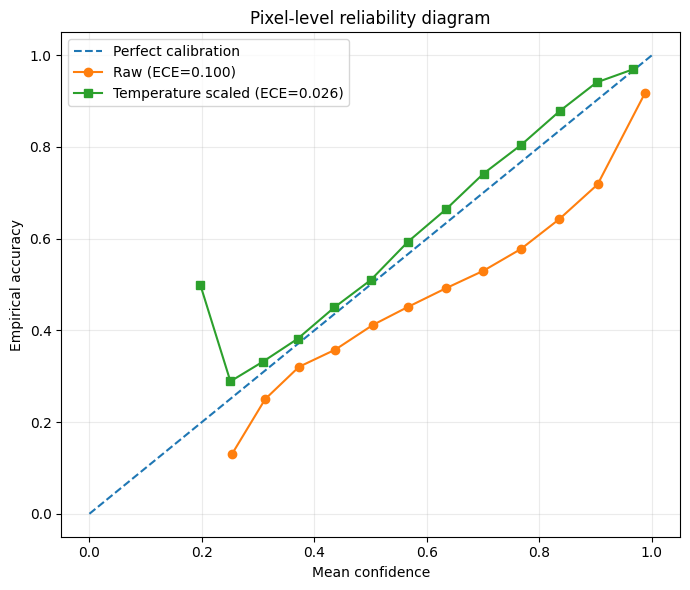

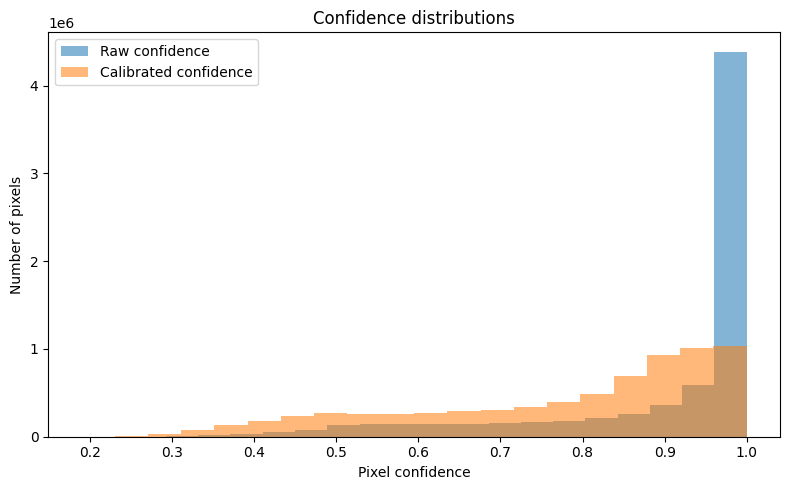

In [86]:
raw_metrics, raw_conf, raw_correct, _ = evaluate_deterministic(baseline_model, test_loader, collect_probabilities=False)
raw_ece, raw_rel = expected_calibration_error(raw_conf, raw_correct)
cal_rel = cal_stats["reliability"]

fig = plt.figure(figsize=(7, 6))
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
if not raw_rel.empty:
    plt.plot(raw_rel["mean_confidence"], raw_rel["accuracy"], marker="o", label=f"Raw (ECE={raw_ece:.3f})")
if not cal_rel.empty:
    plt.plot(cal_rel["mean_confidence"], cal_rel["accuracy"], marker="s", label=f"Temperature scaled (ECE={cal_stats['ece']:.3f})")
plt.xlabel("Mean confidence")
plt.ylabel("Empirical accuracy")
plt.title("Pixel-level reliability diagram")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
fig.savefig(OUTPUT_ROOT / "figures" / "reliability_diagram.png", dpi=180, bbox_inches="tight")
plt.show()

fig = plt.figure(figsize=(8, 5))
plt.hist(raw_conf, bins=20, alpha=0.55, label="Raw confidence")
plt.hist(cal_stats["conf"], bins=20, alpha=0.55, label="Calibrated confidence")
plt.xlabel("Pixel confidence")
plt.ylabel("Number of pixels")
plt.title("Confidence distributions")
plt.legend()
plt.tight_layout()
fig.savefig(OUTPUT_ROOT / "figures" / "confidence_histograms.png", dpi=180, bbox_inches="tight")
plt.show()

## 14. Monte Carlo Dropout Uncertainty

For stochastic logits/probabilities \(p_t(c\mid x)\), the predictive mean is

\[
ar p(c\mid x)=rac{1}{T}\sum_{t=1}^{T}p_t(c\mid x).
\]

The predictive entropy is

\[
H(ar p)=-\sum_c ar p_c\log(ar p_c+\epsilon).
\]

The expected entropy is \(rac{1}{T}\sum_t H(p_t)\). Their difference,

\[
MI=H(ar p)-rac{1}{T}\sum_tH(p_t),
\]

is a common **mutual-information-style epistemic uncertainty proxy** under the stochastic forward-pass approximation. It should not be treated as a perfect separation of aleatoric and epistemic uncertainty.

In [87]:
def enable_mc_dropout(model):
    model.eval()
    count = 0
    for module in model.modules():
        if isinstance(module, (nn.Dropout, nn.Dropout2d, nn.Dropout3d)):
            module.train()
            count += 1
    return count


def mc_predict_single(model, image_tensor, samples=MC_SAMPLES):
    stochastic_count = enable_mc_dropout(model)
    if stochastic_count == 0:
        raise RuntimeError("No dropout layers were found; MC Dropout cannot run.")

    image_tensor = image_tensor.unsqueeze(0).to(DEVICE)
    sample_probs = []
    with torch.no_grad():
        for _ in range(samples):
            with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=AMP_ENABLED):
                logits = model(image_tensor)["out"].float()
            sample_probs.append(torch.softmax(logits, dim=1).squeeze(0).cpu())

    probs = torch.stack(sample_probs, dim=0)  # Tensor shape: [T,C,H,W]
    mean_probs = probs.mean(0)
    entropy_mean = -(mean_probs * torch.log(mean_probs.clamp_min(1e-8))).sum(0)
    entropy_each = -(probs * torch.log(probs.clamp_min(1e-8))).sum(1)
    expected_entropy = entropy_each.mean(0)
    mutual_information = (entropy_mean - expected_entropy).clamp_min(0)
    predictive_variance = probs.var(0, unbiased=False).mean(0)
    confidence, prediction = mean_probs.max(0)

    return {
        "mean_probs": mean_probs,
        "prediction": prediction,
        "confidence": confidence,
        "predictive_entropy": entropy_mean,
        "expected_entropy": expected_entropy,
        "mutual_information": mutual_information,
        "predictive_variance": predictive_variance,
    }

## 15. Uncertainty Evaluation: Error Alignment and Selective Prediction

The main robotics question is not simply whether uncertainty looks interesting. What matters is whether **high uncertainty is statistically associated with mistakes**.

The notebook therefore compares uncertainty with pixel errors and evaluates selective prediction: it keeps only the most confident pixels and measures the remaining error risk.


In [88]:
def evaluate_mc_uncertainty(model, loader, samples=MC_SAMPLES):
    model.eval()
    all_uncertainty, all_correct, all_confidence = [], [], []
    all_images = []
    cm = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)
    per_image_stats = []

    for idx in range(len(loader.dataset)):
        image, target, image_path, mask_path = loader.dataset[idx]
        result = mc_predict_single(model, image, samples=samples)
        pred = result["prediction"]
        correct = pred.eq(target)
        unc = result["mutual_information"].numpy().reshape(-1)
        conf = result["confidence"].numpy().reshape(-1)
        corr = correct.numpy().reshape(-1).astype(np.float32)
        all_uncertainty.append(unc)
        all_confidence.append(conf)
        all_correct.append(corr)
        cm = update_confusion_matrix(cm, pred.unsqueeze(0), target.unsqueeze(0), NUM_CLASSES)
        per_image_stats.append({
            "image_path": image_path,
            "mask_path": mask_path,
            "mean_mi": float(unc.mean()),
            "mean_confidence": float(conf.mean()),
            "error_rate": float(1.0 - corr.mean()),
        })
        all_images.append((image, target, image_path, mask_path, result))

    uncertainty = np.concatenate(all_uncertainty)
    confidence = np.concatenate(all_confidence)
    correct = np.concatenate(all_correct)
    error = 1.0 - correct
    rank_corr = float(pd.Series(uncertainty).corr(pd.Series(error), method="spearman"))
    coverage, risk, aurc = risk_coverage(-uncertainty, correct)

    high_q = np.quantile(uncertainty, 0.90)
    low_q = np.quantile(uncertainty, 0.10)
    high_error = float(error[uncertainty >= high_q].mean())
    low_error = float(error[uncertainty <= low_q].mean())

    summary = {
        "spearman_uncertainty_error": rank_corr,
        "error_rate_top_10pct_uncertainty": high_error,
        "error_rate_bottom_10pct_uncertainty": low_error,
        "uncertainty_error_gap": high_error - low_error,
        "uncertainty_selective_aurc": aurc,
        "segmentation": metrics_from_confusion(cm),
        "per_image": pd.DataFrame(per_image_stats),
    }
    return summary, all_images, uncertainty, confidence, correct

mc_summary, mc_records, mc_uncertainty, mc_confidence, mc_correct = evaluate_mc_uncertainty(
    baseline_model, test_loader, samples=MC_SAMPLES
)
print("MC uncertainty summary:")
print({k: v for k, v in mc_summary.items() if k != "per_image" and k != "segmentation"})
print("MC test mIoU:", mc_summary["segmentation"]["miou"])

pd.DataFrame([{
    "MC_samples": MC_SAMPLES,
    "mIoU": mc_summary["segmentation"]["miou"],
    "mean_Dice": mc_summary["segmentation"]["mean_dice"],
    "spearman_uncertainty_error": mc_summary["spearman_uncertainty_error"],
    "high_vs_low_uncertainty_error_gap": mc_summary["uncertainty_error_gap"],
    "uncertainty_AURC": mc_summary["uncertainty_selective_aurc"],
}]).to_csv(OUTPUT_ROOT / "tables" / "mc_dropout_summary.csv", index=False)
mc_summary["per_image"].to_csv(OUTPUT_ROOT / "metrics" / "mc_dropout_per_image.csv", index=False)

MC uncertainty summary:
{'spearman_uncertainty_error': 0.40694270685290446, 'error_rate_top_10pct_uncertainty': 0.49865028262138367, 'error_rate_bottom_10pct_uncertainty': 0.017597520723938942, 'uncertainty_error_gap': 0.4810527618974447, 'uncertainty_selective_aurc': 0.0741131155326763}
MC test mIoU: 0.40262680108047416


In [89]:
def mc_sample_sensitivity(model, dataset, sample_grid=(4, 8, 12), max_images=6):
    rows = []
    original_pairs = dataset.pairs
    subset = dataset.__class__(original_pairs[:max_images], train=False, image_size=IMAGE_SIZE)
    for n_samples in sample_grid:
        local_unc, local_err = [], []
        for idx in range(len(subset)):
            image, target, _, _ = subset[idx]
            result = mc_predict_single(model, image, samples=n_samples)
            pred = result["prediction"]
            local_unc.append(result["mutual_information"].numpy().reshape(-1))
            local_err.append((pred.numpy() != target.numpy()).astype(np.float32).reshape(-1))
        u = np.concatenate(local_unc)
        e = np.concatenate(local_err)
        corr = float(pd.Series(u).corr(pd.Series(e), method="spearman"))
        rows.append({"mc_samples": n_samples, "mean_uncertainty": float(u.mean()), "spearman_uncertainty_error": corr})
    return pd.DataFrame(rows)

mc_sensitivity_df = mc_sample_sensitivity(baseline_model, test_dataset)
mc_sensitivity_df.to_csv(OUTPUT_ROOT / "tables" / "mc_sample_sensitivity.csv", index=False)
display(mc_sensitivity_df)


,mc_samples,mean_uncertainty,spearman_uncertainty_error
0,4,0.009721,0.485160
1,8,0.012350,0.502451
2,12,0.011869,0.526764


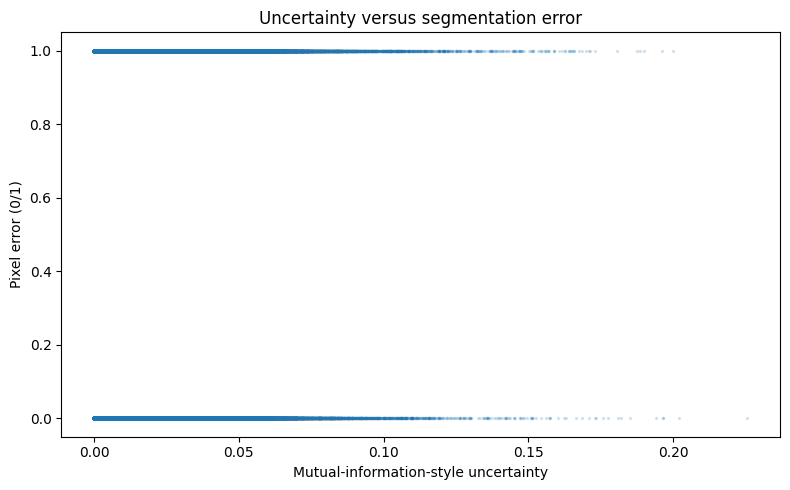

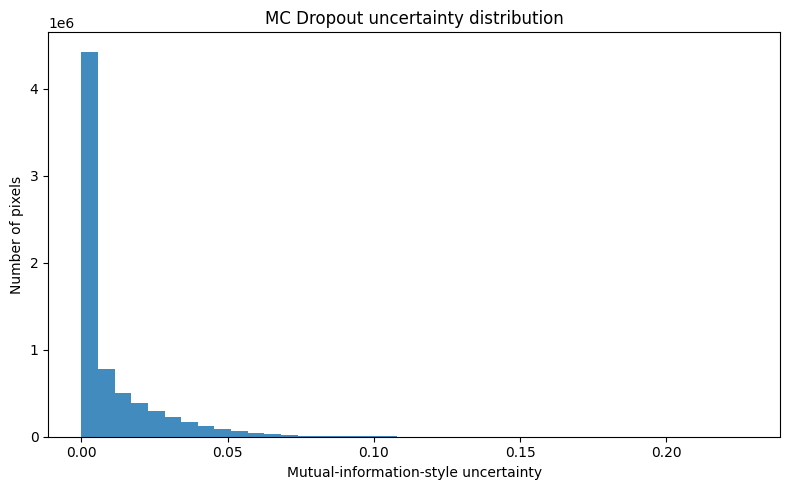

In [90]:
fig = plt.figure(figsize=(8, 5))
plt.scatter(mc_uncertainty[::20], (1 - mc_correct)[::20], s=2, alpha=0.15)
plt.xlabel("Mutual-information-style uncertainty")
plt.ylabel("Pixel error (0/1)")
plt.title("Uncertainty versus segmentation error")
plt.tight_layout()
fig.savefig(OUTPUT_ROOT / "figures" / "uncertainty_vs_error.png", dpi=180, bbox_inches="tight")
plt.show()

fig = plt.figure(figsize=(8, 5))
plt.hist(mc_uncertainty, bins=40, alpha=0.85)
plt.xlabel("Mutual-information-style uncertainty")
plt.ylabel("Number of pixels")
plt.title("MC Dropout uncertainty distribution")
plt.tight_layout()
fig.savefig(OUTPUT_ROOT / "figures" / "uncertainty_histogram.png", dpi=180, bbox_inches="tight")
plt.show()

## 16. Qualitative Segmentation and Uncertainty Maps

The examples below show the raw image, ground truth, prediction, error map, confidence, and uncertainty. The same palette is used for ground truth and predictions so class confusion is easy to inspect.


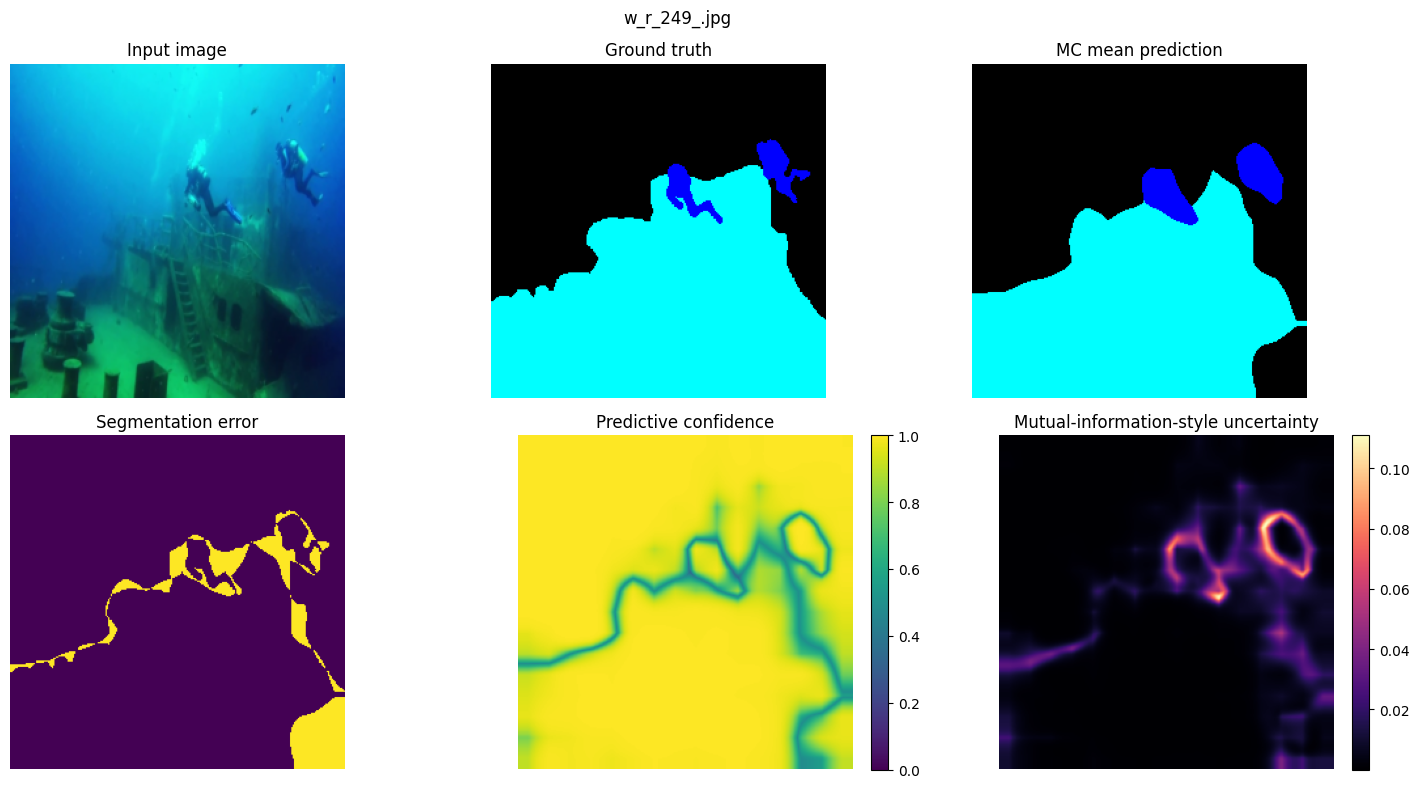

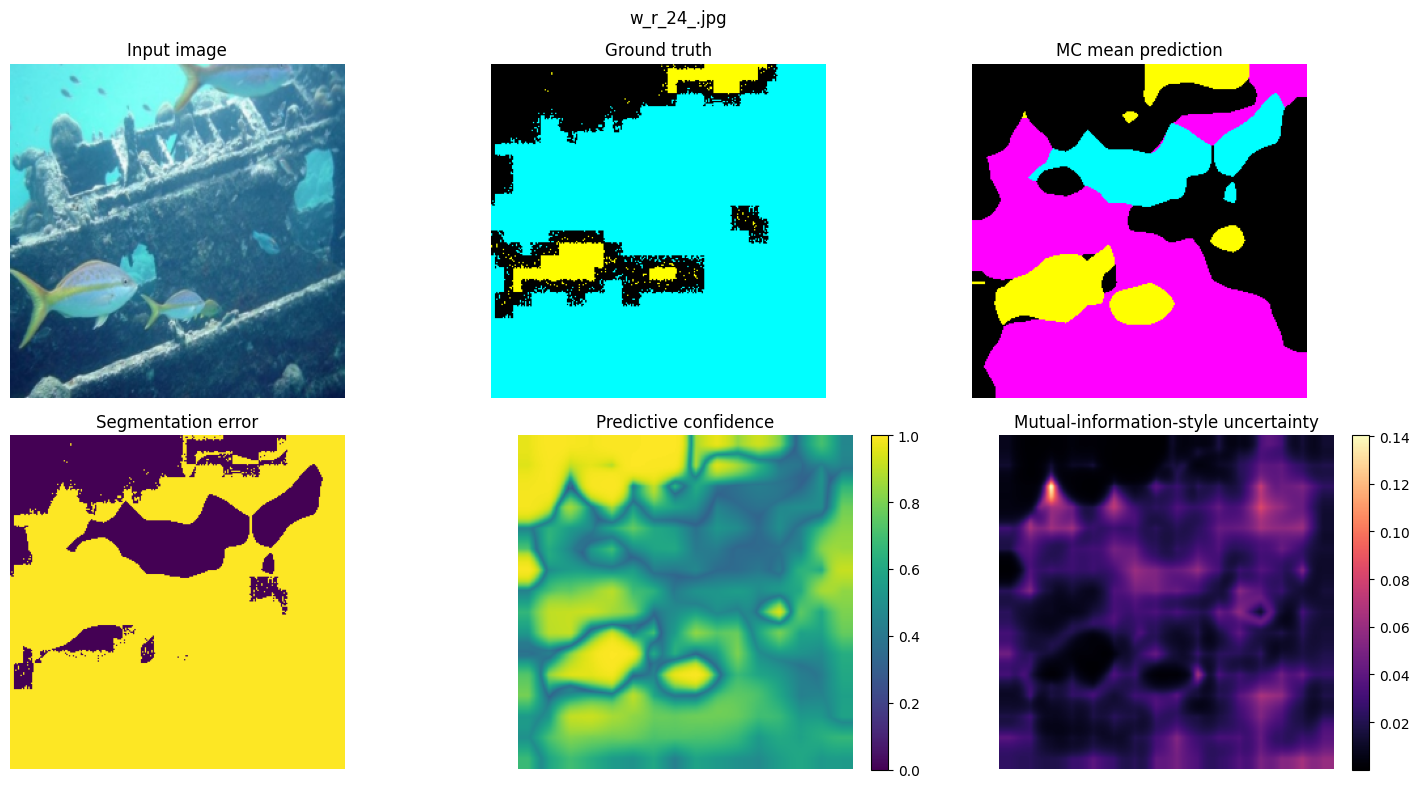

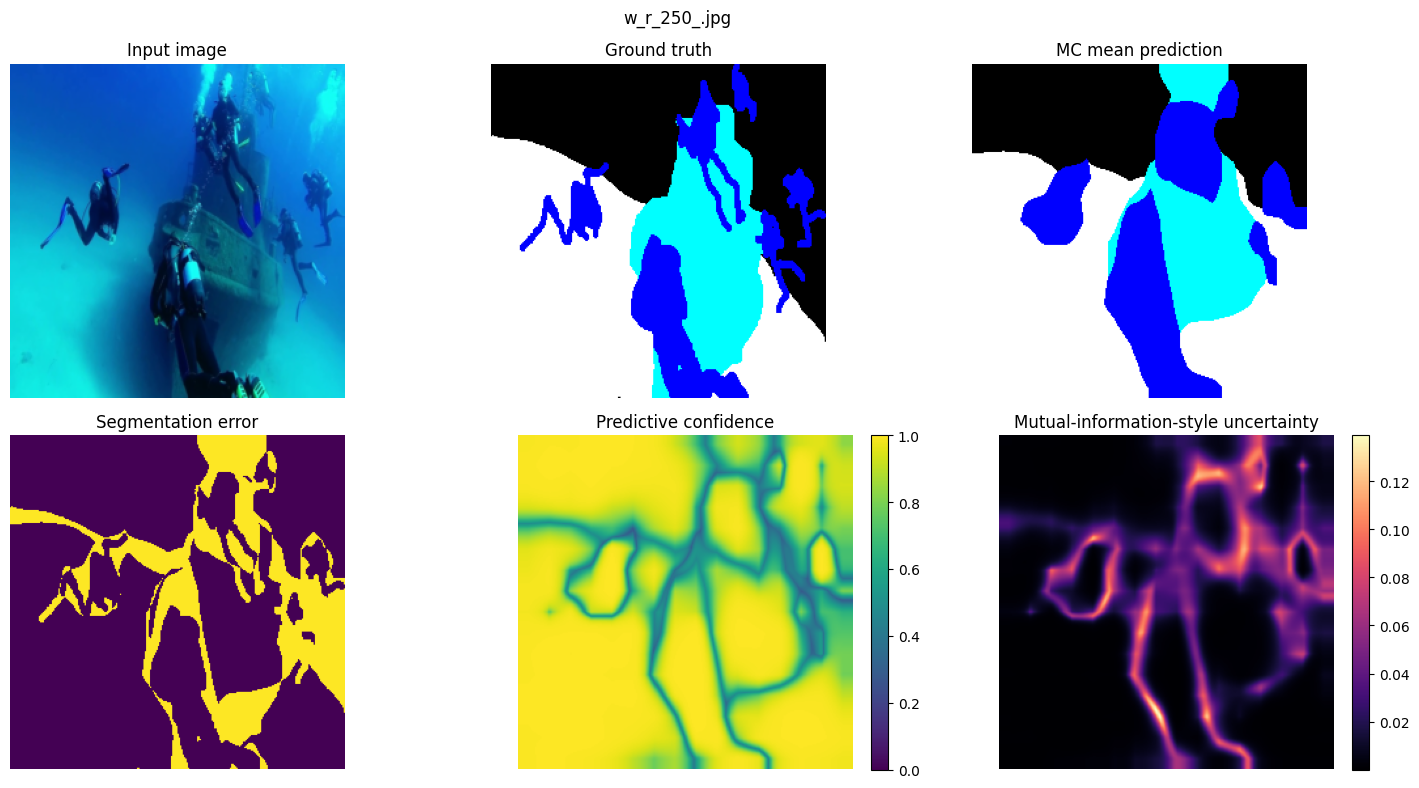

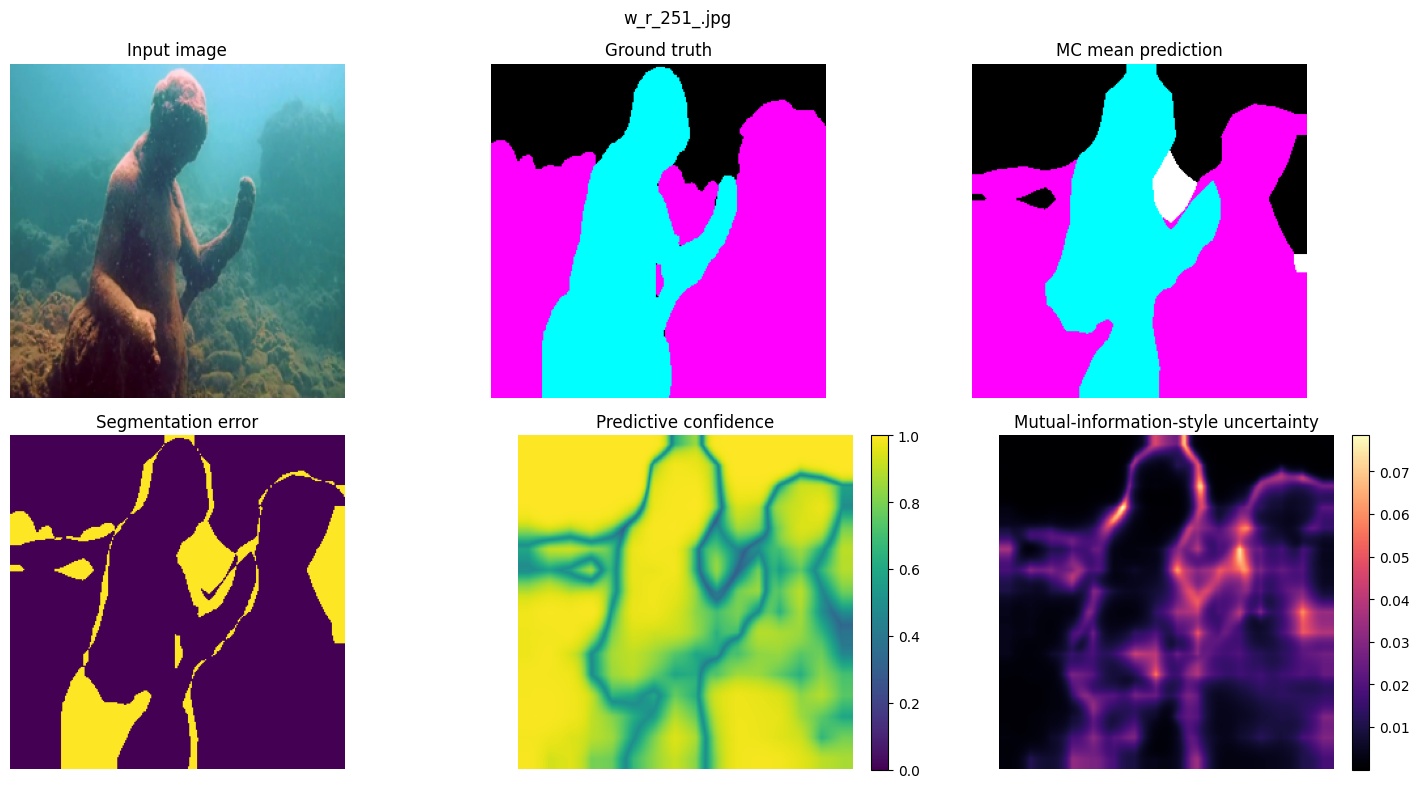

In [91]:
def denormalize_image(tensor):
    img = tensor.clone()
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    img = img * std + mean
    return img.clamp(0, 1).permute(1, 2, 0).numpy()


def colorize_mask(mask_ids):
    return CLASS_RGB[np.asarray(mask_ids)]


def save_qualitative_examples(records, n=4):
    selected = records[:n]
    for sample_i, (image, target, image_path, mask_path, result) in enumerate(selected, start=1):
        pred = result["prediction"].numpy()
        target_np = target.numpy()
        image_np = denormalize_image(image)
        conf = result["confidence"].numpy()
        mi = result["mutual_information"].numpy()
        error = (pred != target_np).astype(np.float32)
        mi_norm = mi / max(float(mi.max()), 1e-8)
        mi_rgb = (plt.get_cmap("magma")(mi_norm)[..., :3] * 255).astype(np.uint8)
        overlay = np.clip(0.65 * image_np * 255.0 + 0.35 * mi_rgb, 0, 255).astype(np.uint8)

        fig, axes = plt.subplots(2, 3, figsize=(15, 8))
        axes[0, 0].imshow(image_np)
        axes[0, 0].set_title("Input image")
        axes[0, 1].imshow(colorize_mask(target_np))
        axes[0, 1].set_title("Ground truth")
        axes[0, 2].imshow(colorize_mask(pred))
        axes[0, 2].set_title("MC mean prediction")
        im1 = axes[1, 0].imshow(error, vmin=0, vmax=1)
        axes[1, 0].set_title("Segmentation error")
        im2 = axes[1, 1].imshow(conf, vmin=0, vmax=1, cmap="viridis")
        axes[1, 1].set_title("Predictive confidence")
        im3 = axes[1, 2].imshow(mi, cmap="magma")
        axes[1, 2].set_title("Mutual-information-style uncertainty")
        for ax in axes.ravel():
            ax.axis("off")
        fig.colorbar(im2, ax=axes[1, 1], fraction=0.046, pad=0.04)
        fig.colorbar(im3, ax=axes[1, 2], fraction=0.046, pad=0.04)
        plt.suptitle(Path(image_path).name)
        plt.tight_layout()

        base = OUTPUT_ROOT / "predictions" / f"sample_{sample_i:03d}"
        fig.savefig(base.with_suffix(".png"), dpi=180, bbox_inches="tight")
        Image.fromarray((mi / max(mi.max(), 1e-8) * 255).astype(np.uint8)).save(
            OUTPUT_ROOT / "uncertainty_maps" / f"sample_{sample_i:03d}_mi.png"
        )
        Image.fromarray(colorize_mask(pred)).save(OUTPUT_ROOT / "predictions" / f"sample_{sample_i:03d}_prediction.png")
        Image.fromarray((error * 255).astype(np.uint8)).save(OUTPUT_ROOT / "predictions" / f"sample_{sample_i:03d}_error.png")
        Image.fromarray((conf * 255).astype(np.uint8)).save(OUTPUT_ROOT / "uncertainty_maps" / f"sample_{sample_i:03d}_confidence.png")
        Image.fromarray(overlay).save(OUTPUT_ROOT / "uncertainty_maps" / f"sample_{sample_i:03d}_overlay.png")
        plt.show()

save_qualitative_examples(mc_records, n=min(4, len(mc_records)))

## 17. Per-Class Results

,class_id,class,IoU,Dice
0,0,Background / waterbody,0.787968,0.881412
1,1,Human divers,0.583888,0.737284
2,2,Aquatic plants / sea-grass,0.169233,0.289477
3,3,Wrecks / ruins,0.719870,0.837122
4,4,Robots / instruments,0.000000,0.000000
5,5,Reefs / invertebrates,0.298332,0.459562
6,6,Fish / vertebrates,0.139301,0.244538
7,7,Sea-floor / rocks,0.526094,0.689465


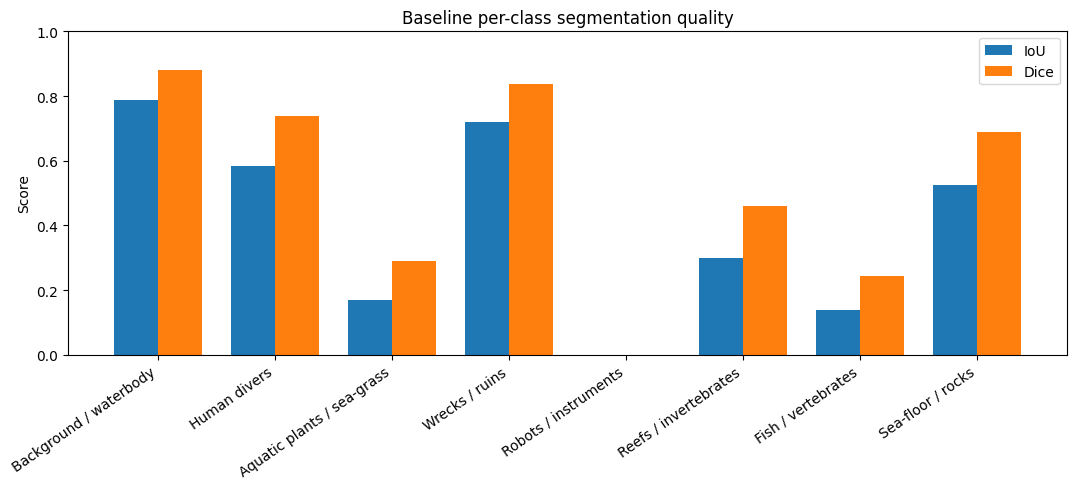

In [92]:
baseline_metrics, _, _, _ = evaluate_deterministic(baseline_model, test_loader, collect_probabilities=False)
per_class_df = pd.DataFrame({
    "class_id": np.arange(NUM_CLASSES),
    "class": CLASS_NAMES,
    "IoU": baseline_metrics["per_class_iou"],
    "Dice": baseline_metrics["per_class_dice"],
})
per_class_df.to_csv(OUTPUT_ROOT / "tables" / "baseline_per_class_metrics.csv", index=False)
display(per_class_df)

fig = plt.figure(figsize=(11, 5))
x = np.arange(NUM_CLASSES)
width = 0.38
plt.bar(x - width / 2, per_class_df["IoU"], width=width, label="IoU")
plt.bar(x + width / 2, per_class_df["Dice"], width=width, label="Dice")
plt.xticks(x, CLASS_NAMES, rotation=35, ha="right")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Baseline per-class segmentation quality")
plt.legend()
plt.tight_layout()
fig.savefig(OUTPUT_ROOT / "figures" / "per_class_metrics.png", dpi=180, bbox_inches="tight")
plt.show()

## 18. Compact Experiment Summary

This section collects the main quantitative results generated above. No values are entered manually.


In [93]:
final_summary = comparison_df.copy()
final_summary["temperature"] = np.nan
final_summary.loc[final_summary["experiment"] == "experiment_01_baseline_ce_dice", "temperature"] = temperature
final_summary["MC_samples"] = np.nan
final_summary.loc[final_summary["experiment"] == "experiment_01_baseline_ce_dice", "MC_samples"] = MC_SAMPLES
final_summary["uncertainty_spearman"] = np.nan
final_summary.loc[final_summary["experiment"] == "experiment_01_baseline_ce_dice", "uncertainty_spearman"] = mc_summary["spearman_uncertainty_error"]
final_summary.to_csv(OUTPUT_ROOT / "tables" / "final_experiment_summary.csv", index=False)
display(final_summary)

,experiment,pixel_accuracy,mIoU,mean_Dice,ECE,AURC,mean_confidence,mean_inference_sec_per_image,train_time_sec,optimizer,loss_mode,learning_rate,batch_size,image_size,dropout,mc_samples,temperature,MC_samples,uncertainty_spearman
0,experiment_01_baseline_ce_dice,0.803248,0.403086,0.517358,0.099660,0.068912,0.902907,0.003163,1143.268354,AdamW,ce_dice,0.0003,8,256,0.2,8,1.880789,8.0,0.406943
1,experiment_02_ablation_ce_only,0.800772,0.403018,0.519017,0.091771,0.070202,0.892506,0.005039,1163.242220,AdamW,ce_only,0.0003,8,256,0.2,0,NaN,NaN,NaN


## 19. Robotics Interpretation

The useful robotics signal is **not** “the model is uncertain, therefore the robot must stop.” The evidence supports a more cautious interpretation:

- If high-uncertainty pixels have a higher observed error rate than low-uncertainty pixels, uncertainty can serve as a **risk indicator**.
- A planner could use a conservative perception policy: slow down, widen obstacle margins, request additional sensing, revisit a view, or defer object interaction when a relevant region is uncertain.
- Temperature scaling can make confidence easier to interpret, but calibration does not automatically create robust perception under domain shift.
- SUIM is a benchmark, not a substitute for validating uncertainty on a specific robot camera, depth sensor, lighting configuration, vehicle, or operational environment.

These are downstream design implications, not claims of deployment readiness.


## 20. Limitations

1. **Small benchmark size:** SUIM contains roughly 1.5k train/validation images and 110 test images, so confidence intervals across environments can remain wide.
2. **Domain shift:** performance and uncertainty behavior may change for a new camera, water body, depth, illumination condition, or sensor pipeline.
3. **Approximate epistemic uncertainty:** MC Dropout is a stochastic approximation, not exact posterior inference.
4. **Aleatoric uncertainty is not explicitly modeled:** high predictive entropy can come from both data ambiguity and model uncertainty; the notebook does not claim a clean decomposition.
5. **Calibration is distribution-dependent:** a temperature learned on SUIM validation pixels may not remain calibrated on another deployment distribution.
6. **Pixel dependence:** pixel-level metrics treat pixels as samples even though neighboring pixels are strongly correlated.
7. **Compute trade-off:** MC Dropout multiplies inference work by the number of stochastic passes.


## 21. Reproducibility Record

The notebook stores the seed, hyperparameters, model checkpoint metadata, training history, validation-based temperature, and output tables. GPU kernels can still introduce small differences across hardware/software combinations, so the project does not claim bitwise identity across all Colab runtimes.


In [94]:
repro_record = {
    "seed": SEED,
    "python": sys.version,
    "torch": torch.__version__,
    "device": str(DEVICE),
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "mc_samples": MC_SAMPLES,
    "calibration_pixels": CALIBRATION_PIXELS,
    "train_count": len(train_split),
    "val_count": len(val_split),
    "test_count": len(test_pairs),
    "dataset_root": str(DATA_ROOT),
}
save_json(repro_record, OUTPUT_ROOT / "configs" / "reproducibility_record.json")
print(json.dumps(repro_record, indent=2, default=str))

{
  "seed": 20260827,
  "python": "3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]",
  "torch": "2.11.0+cu128",
  "device": "cuda",
  "gpu": "Tesla T4",
  "image_size": 256,
  "batch_size": 8,
  "epochs": 25,
  "learning_rate": 0.0003,
  "weight_decay": 0.0001,
  "mc_samples": 8,
  "calibration_pixels": 100000,
  "train_count": 1283,
  "val_count": 227,
  "test_count": 110,
  "dataset_root": "/content/suim_data"
}


## 22. Save, Verify, and Package Results

The project output tree is organized so another researcher can inspect checkpoints, metrics, tables, figures, uncertainty maps, configurations, and logs without depending on notebook state.


In [95]:
def list_outputs(root: Path):
    rows = []
    for p in sorted(root.rglob("*")):
        if p.is_file():
            rows.append({"path": str(p.relative_to(root)), "bytes": p.stat().st_size})
    return pd.DataFrame(rows)

output_df = list_outputs(OUTPUT_ROOT)
expected_files = [
    OUTPUT_ROOT / "tables" / "comparison_table.csv",
    OUTPUT_ROOT / "tables" / "calibration_summary.csv",
    OUTPUT_ROOT / "tables" / "mc_dropout_summary.csv",
    OUTPUT_ROOT / "tables" / "final_experiment_summary.csv",
    OUTPUT_ROOT / "figures" / "reliability_diagram.png",
    OUTPUT_ROOT / "figures" / "uncertainty_vs_error.png",
    experiment_checkpoints["experiment_01_baseline_ce_dice"],
]
missing = [str(p) for p in expected_files if not p.exists()]
print(f"Saved files: {len(output_df)}")
if missing:
    print("Missing expected outputs:", missing)
else:
    print("All core expected outputs are present.")

display(output_df.head(40))

Saved files: 54
All core expected outputs are present.


,path,bytes
0,REPORT.md,1996
1,checkpoints/experiment_01_baseline_ce_dice_bes...,44350775
2,checkpoints/experiment_02_ablation_ce_only_bes...,44350775
3,configs/experiment_01_baseline_ce_dice.json,310
4,configs/experiment_02_ablation_ce_only.json,310
5,configs/reproducibility_record.json,420
6,configs/temperature_scaling.json,71
7,figures/confidence_histograms.png,41477
8,figures/dataset_class_distribution.png,100215
9,figures/dataset_samples.png,5029435


In [96]:
# Save a compact project report so the ZIP can be reviewed without opening the notebook.
report = f"""# Uncertainty-Aware Underwater Semantic Segmentation for Robotics

Dataset: SUIM

Train images: {len(train_split)}
Validation images: {len(val_split)}
Held-out test images: {len(test_pairs)}

Primary model: DeepLabV3 + MobileNetV3-Large
MC Dropout samples: {MC_SAMPLES}
Learned temperature: {temperature:.6f}

## Key generated metrics

{final_summary.to_markdown(index=False)}

## Scientific interpretation

This report contains only metrics computed during notebook execution. MC Dropout uncertainty is treated as an approximate stochastic uncertainty signal, and temperature scaling is fitted on validation pixels only.

## Limitations

See the notebook's Limitations section for domain-shift, calibration, uncertainty-approximation, and dataset-size caveats.
"""
(OUTPUT_ROOT / "REPORT.md").write_text(report, encoding="utf-8")

1996

## 23. Final Cell — Package and Automatically Download the Results

**This is intentionally the last executable cell.** It verifies the output tree, creates a ZIP archive, prints the included files, and triggers a Google Colab browser download.


In [97]:
# Final cell: do not add executable cells after this one.
import zipfile

zip_path = Path("/content/SUIM_uncertainty_segmentation_results.zip")
if zip_path.exists():
    zip_path.unlink()

output_df = list_outputs(OUTPUT_ROOT)
assert len(output_df) > 0, "No output files were produced."

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for file_path in sorted(OUTPUT_ROOT.rglob("*")):
        if file_path.is_file():
            zf.write(file_path, arcname=str(file_path.relative_to(OUTPUT_ROOT)))

print(f"Created: {zip_path}")
print(f"ZIP size: {zip_path.stat().st_size / 1024**2:.2f} MB")
print("Included files:", len(output_df))
print(output_df.to_string(index=False))

try:
    from google.colab import files
    files.download(str(zip_path))
    print("Colab download triggered.")
except Exception as exc:
    print("Automatic browser download is available only inside Google Colab.")
    print(f"Archive path: {zip_path}")
    print(f"Download helper message: {exc}")

Created: /content/SUIM_uncertainty_segmentation_results.zip
ZIP size: 87.55 MB
Included files: 54
                                                        path    bytes
                                                   REPORT.md     1996
          checkpoints/experiment_01_baseline_ce_dice_best.pt 44350775
          checkpoints/experiment_02_ablation_ce_only_best.pt 44350775
                 configs/experiment_01_baseline_ce_dice.json      310
                 configs/experiment_02_ablation_ce_only.json      310
                         configs/reproducibility_record.json      420
                            configs/temperature_scaling.json       71
                           figures/confidence_histograms.png    41477
                      figures/dataset_class_distribution.png   100215
                                 figures/dataset_samples.png  5029435
                               figures/per_class_metrics.png   106782
                             figures/reliability_diagram.png  

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Colab download triggered.
